# Tests and counterfactuals

The model's predictions interrogated one test at a time, and the counterfactuals that
switch each force off. The companion notebook, `model_report.ipynb`, reports the FIT of
the same model to its targets.

Every economy here -- the estimated one and both counterfactuals -- is simulated in
Python from the extended parameter set `theta+`, by one forward map. `suppliers.parquet`
is not read: it is the input to `check_against_julia`, the exact cross-language check,
and nothing else.

Each section runs on its own after the imports and the Constants cell.


In [20]:
%pip install matplotlib pandas statsmodels seaborn geopandas pyfixest pyarrow scipy



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [21]:
# The libraries. Every function this notebook calls lives in one of them, so a section
# is edited in a file rather than in a 1,400-line cell, and the gates under `test/`
# import the same code instead of slicing it out of the notebook's JSON.
#
#   utils.py          the loader, `theta+`, the Ricardian geometry, and THE ECONOMY
#   diffusion_lib.py  amplification, the local share, incidence, the IO benchmark
#   granular_lib.py   comparative advantage, concentration, portfolios, the local share
#                     dispersion
#
# Reload after editing one of them: `import importlib; importlib.reload(utils)` --
# or restart the kernel, which is safer once several modules have changed.
import os
import re
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import utils
import diffusion_lib
import granular_lib
from utils import *
from diffusion_lib import *
from granular_lib import *


In [22]:
# Set the width of your LaTeX document in points

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
cmap = plt.get_cmap('viridis')

toulouse_color = (132/255, 46/255, 27/255)
document_width_pt = 511.
font_size = 20  # Adjust according to your preference
plt.rcParams.update({
    "font.size": font_size,
    "axes.labelsize": font_size,
    "axes.titlesize": font_size+2,
    "xtick.labelsize": font_size-3,
    "ytick.labelsize": font_size-3,
    "legend.fontsize": font_size-3,
    "legend.title_fontsize": font_size,
    "figure.titlesize": font_size,
})

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amssymb}",
})


## Constants

In [23]:
# mu = 1 -> step1 best parameters (theta_hat_1)
# mu = 2 -> step3 best parameters (theta_hat_2, the efficient estimate)
MU = 2

# Joint reporting: both industries in one table, one figure set each.
INDUSTRIES = [{"industry": "auto", "display_name": "Motor Vehicles"},
              {"industry": "aero", "display_name": "Aerospace"}]

# The run tree, and WHICH PARTS of it to read. `parts` is the specialisation: this
# notebook reports no moment fit, no inference and no Jacobian, so it reads none of
# those artefacts and opens a tree that carries none of them. It does not read
# `suppliers.parquet` either -- every economy here is simulated from `theta+`.
#
# Add "firm" to compare against Julia's own realisation with `check_against_julia`.
RUN_KWARGS = dict(base="..", profile_T=True, ca_level="aa",
                  granular=True, relax_n_lo=True, optimizer="pso",
                  parts=("core", "geography"))

# How many economies each regime draws. `None` takes `utils.ECONOMY_REPLICATIONS`.
# The Julia-side knob is `POST_HOC_REPLICATIONS` in `main.jl` and is a DIFFERENT
# quantity: it governs how many economies are solved and written for the verification
# artefact, which nothing below reads.
ECONOMY_REPLICATIONS = 1000

# Radii for the amplification section; the FIRST is the headline one.
AMPLIFICATION_RADII = (100, 200)
# Test 8 sweeps the similarity threshold rather than defending one value.
PORTFOLIO_TAUS = (0.6, 0.7, 0.8)

# The constants above override the module defaults, so push them where the library
# functions will resolve them. (A module reads its OWN globals, which is what makes a
# stub work in the gates; the same mechanism applies here.)
for _m in (utils, diffusion_lib, granular_lib):
    for _k in ("AMPLIFICATION_RADII", "PORTFOLIO_TAUS", "ECONOMY_REPLICATIONS"):
        if hasattr(_m, _k):
            setattr(_m, _k, globals()[_k])

out_folder = "../reporting_combined"
os.makedirs(out_folder, exist_ok=True)


## Loading

`utils.load_granular_data(industry, mu, parts=...)` rebuilds, on the Python side, the
layout `load_parameters.jl` builds under `--granular=true --ca_level=aa`, and reads only
the parts it is asked for. This notebook asks for `("core", "geography")`: it reports no
moment fit, no inference and no Jacobian, so it reads none of those artefacts and opens a
run tree that carries none of them.

`utils.reporting_data(industry, mu, ...)` is the entry point the sections use. It loads
the run, reads `theta+` off it, and simulates every regime in `CF_REGIMES` from that one
parameter set, returning `{regime: data}` where each `data` carries that regime's own
economy in `suppliers.parquet`'s schema. The result is cached, so the sections share one
solve.


## The extended parameter set, and the economy it defines

`best_params` is the vector the optimiser searched, and it is **not** the parameter of the
economy. Comparative advantage $T$ is the Sinkhorn image of the $\gamma$ target and the
variety count $N_s$ is an integer bisection on $\bar G_s(0)$: both are calibrated *inside*
the model, so neither is a coordinate of the search, and both are parameters of the economy
all the same. Written down together they are the **extended parameter set**

$$\theta^{+} = \bigl(\Omega^{L},\ \Omega^{s},\ A,\ \alpha,\ T,\ N\bigr),$$

alongside the calibration the run fixes and does not estimate ($\theta$, $\nu_s$, $\nu$,
$\lambda$, $\varepsilon$, $\delta_r$, $w_r$). Two properties bound what "the same
parameter" can mean. $\theta^{+}$ is **gauge-indeterminate** — only $T_{s\cdot}/T_{s,\text{ref}}$
is identified — so equality is asserted after the per-sector reference normalisation and in
no other coordinates. And $N$ is an **integer**, never interpolated: a counterfactual holds
it fixed, because re-running the bisection under a new geometry would recalibrate a moment
rather than answer a counterfactual.

**Given $\theta^{+}$ and the draws the economy is a deterministic forward map with no fixed
point.** That is the fact which makes one implementation enough. An upstream cell's
delivered cost is $w_l\,\tau_{lr}/z_{\rho l}$ with $w_r$ normalised to one and *no upstream
price index in it*, so nothing downstream feeds back and the chain runs one way:

$$\text{winners}\ \longrightarrow\ P_{sr}\ \longrightarrow\ P_r\ \longrightarrow\ c_r,\ \tilde c_r\ \longrightarrow\ P,\ Y_r\ \longrightarrow\ \text{flows}.$$

`simulate_economy` is that map, step for step as `solve_network` runs it, and it is used for
**every** regime including the estimated one. Three consequences are worth stating because
they are what the earlier two-route arrangement could not deliver. The counterfactuals stop
being a different *kind* of object from the baseline — one implementation, one set of
conventions, so a discrepancy is a bug rather than a modelling difference. The value block
comes out of the economy rather than being read off the baseline parquet, so $D_r$,
$\tilde c_r$, $Y_r$ and the **input mix $\theta_{rs}$** are available *per regime*: the
current figures hold $\theta_{rs}$ at its mean, which was the right dodge while the input
mix could not be recomputed and is now a choice to be made rather than a constraint. And
because the estimated economy is also the one Julia writes to `suppliers.parquet`, that file
becomes the **reference the Python route is gated against** rather than a second opinion —
with the same draws the two must agree to the bit, which is a test, where two independent
simulators could only ever agree approximately.

Four conventions have to match for that bit-agreement, and none of them is economics: the
Fréchet branch ($1-u$, not $u$), the column order of the draw matrix (`findall` on an
$(S,R)$ mask walks it **column-major**, so the good index runs region-outer and
sector-inner — read it backwards and one cell's draws are used for another, giving a
perfectly plausible wrong economy), the within-sector versus total-cost normalisation of the
expenditure share, and the draw stream itself. The last cannot be reproduced across the two
languages — Julia's `MersenneTwister` generates `Float64` through dSFMT and numpy's
`default_rng` does not — so exact agreement requires Julia to **write its draws**, which is
a few MB, rather than Python to imitate the generator.

One caveat that is not a convention. $\hat\theta$ was fit to the **continuum** economy
(flat $1/N_\rho$ weights over $N_\rho$ draws, the $N_s\to\infty$ limit), so the finite-$N$
economy at that same $\hat\theta$ does not reproduce the targets — `write_post_hoc` measures
the gap. "The same object" therefore means the finite-$N$ economy at $\hat\theta$, not the
economy the estimator targeted.

---

**Where the code lives.** `Economy`, `extended_parameters`, `simulate_economy`,
`economy_identities`, `economy_frame`, `simulated_data`, `economy_by_regime`,
`continuum_economy` and `check_against_julia` are in `utils.py`. Edit them there and
either `importlib.reload(utils)` or restart the kernel.

In [24]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
# theta+ read off the run, then EVERY economy simulated from it -- the estimated one and
# both counterfactuals, by one map, with N held fixed. Each comes back with its own frame
# in `suppliers.parquet`'s schema, so `build_diffusion_frame`, `_sector_spend`,
# `variety_panel` and the rest read a counterfactual through exactly the code they read
# the estimate through.
#
# `suppliers.parquet` is NOT read here. It is the input to `check_against_julia`, which
# compares this port against `solve_network` to the bit given Julia's own draws -- the one
# exact check available, since the identities cannot catch a hand transcription that is
# self-consistently wrong. Run it after any change to either implementation:
#
#     d = load_granular_data("aero", mu=MU, **{**RUN_KWARGS, "parts": ("core", "firm")})
#     check_against_julia(d)
ECONOMIES = {}
for cfg in INDUSTRIES:
    industry, name = cfg["industry"], cfg.get("display_name", cfg["industry"])
    print(f"\n=== [{industry}, mu = {MU}] " + "=" * 46)
    try:
        regs = reporting_data(industry, mu=MU, n_rep=ECONOMY_REPLICATIONS, **RUN_KWARGS)
    except (FileNotFoundError, KeyError, ValueError) as e:
        print(f"  skipped: {type(e).__name__}: {e}")
        continue
    for reg, dl in regs.items():
        ECONOMIES[(name, reg)] = dl

    # The value block, per regime. D_r, the price indices and the INPUT MIX now move with
    # the regime; under the two-route arrangement they were read off the baseline and held
    # fixed, which is why the section's figures still hold theta_rs at its mean. Whether
    # they should is now a choice rather than a limitation.
    rows = []
    for reg, dl in regs.items():
        V = dl["economy"].value
        rows.append({"regime": reg, "D_r": V["D_r"].mean(), "P_r": V["P_r"].mean(),
                     "c_tilde_r": V["c_tilde_r"].mean(),
                     "Y_r (sum)": V["Y_r"].sum(axis=1).mean(),
                     "mix sd across s": float(V["theta_rs"].mean(axis=0).std(axis=0).mean()),
                     "n_rep": dl["economy"].meta["n_rep"]})
    display(pd.DataFrame(rows).set_index("regime").round(4))



=== [auto, mu = 2] ==============================================


,D_r,P_r,c_tilde_r,Y_r (sum),mix sd across s,n_rep
regime,,,,,,
Both forces,1.8323,0.1183,0.2112,1.0,0.0599,1000
Equal comparative advantage,1.7913,0.0690,0.1363,1.0,0.0610,1000
No trade cost,1.7843,0.0635,0.1276,1.0,0.0601,1000



=== [aero, mu = 2] ==============================================


,D_r,P_r,c_tilde_r,Y_r (sum),mix sd across s,n_rep
regime,,,,,,
Both forces,1.8694,0.5541,0.6595,1.0,0.1797,1000
Equal comparative advantage,1.8172,0.2490,0.3350,1.0,0.1684,1000
No trade cost,1.7621,0.1277,0.1979,1.0,0.1811,1000


# Amplification and spatial diffusion of downstream shocks

Section 5.1 of the paper. A demand shock lands on a downstream region; the model says how
much upstream activity it generates and where that activity goes. Those are two different
questions, and the second splits into three more, so the section is run as **eight tests**
taken one at a time.

| | Question | Statistic | What the answer looks like |
|---|---|---|---|
| 1 | How large is the response? | $D_r = 1 + \sum_l X_{lr}$ | A number near 1.85, nearly flat across regions — but NOT flat across regimes: $T$ and $\alpha$ set $P_r$, and with $\lambda < 1$ that moves the intermediate expenditure share |
| 2 | Is that large? | Leontief multipliers from the IO table | The model captures one upstream tier; the benchmark says what share of the aggregate that is |
| 3 | How far does the response travel? | $d_r$, the average sourcing distance | ~350 km in both industries — a level that identifies nothing on its own |
| 4 | Which force keeps the euro close? | $d_r$ with one force switched off | Auto held close by capability, aero by proximity |
| 5 | Where does the response land? | concentration and commonality of $\omega_r$ | Hub-and-spoke = concentrated **and** common |
| 6 | How much does the region keep, and how reliably? | $L_r(d)$ as a level $\pm$ a dispersion | The sign reversal: in aero, capability *lowers* the local share. The level is the continuum benchmark exactly, so all of granularity is in the band |
| 7 | What does finite $N_s$ cost? | granular vs continuum | The expected shares are invariant; the **support** is not |
| 8 | Do suppliers share a clientele? | cosine between customer portfolios | A high mean similarity is compatible with strong segmentation and with none |

Tests 1–2 are about the SIZE of the response, 3–6 about its INCIDENCE. Test 8 turns the
same matrix on its side and reads the SUPPLIER's portfolio of customers. Granularity is not a
caveat on the others but a measurement in its own right: with $N_s$ finite the network is a
random object, so what it moves is how many origins one shock reaches (test 7) and how far one
realisation of the local share can sit from its own expectation (the second half of test 6,
which used to be a test 9 of its own — one statistic, so one test).

**Three conventions set the LEVEL of $D_r$ and are worth stating before any number is read.**
`share` is `exp_val`, a share of the downstream firm's UNIT COST, and the markup $\mu$ is not
applied — the published figure's convention. `intermediate_derivative` is that quantity
renormalised WITHIN intermediates, so it sums to one and is *not* an amplification measure. And
the model has one upstream tier, so $D_r$ is the whole of its amplification, with no round-2
Leontief term — which is exactly what test 2 puts a number on.

Each test runs on its own after the imports, the Constants cell and the economy cell above.
Everything they call is imported from `utils`, `diffusion_lib` and `granular_lib`; there are no
definition cells to run first.


## Test 1 — how large is the upstream response?

$D_r$ is the aggregate increase in sales generated by one additional euro of final demand in
downstream region $r$: the euro itself, plus what it pulls upstream. Summing `share` over
every supplying firm gives $r$'s intermediate-input share, so

$$D_r = 1 + \sum_l X_{lr}.$$

**It has a closed form, and that is the test's real content.** Summing `exp_val` over the
varieties of a sector kills the within-sector CES index exactly, and summing over sectors
kills the across-sector one, leaving $D_r = 1 + (1-\Omega_L)(P_r/c_r)^{1-\lambda}$. So $D_r$
is a COST-SHARE object: the comparative-advantage parameters do not appear in it. Two
consequences follow. The identification of $T$ only up to $w^\theta T$ does **not**
contaminate $D_r$ — that conflation shapes the geography of a shock, not its size. And the
only regional term is $(P_r/c_r)^{1-\lambda}$, local access to cheap inputs, which is why the
coefficients come out nearly flat across commuting zones.

The variety-count check runs first. A wrong variety count is not a detail of the input; it is
a different model, and everything below is built on that parquet.



  mean D_r = 1.832 (one euro of demand -> 0.832 upstream), p90 = 1.833


,region,upstream_sales,amplification,supplier_cells,mean_upstream_distance,share_within_100km,share_within_200km
ze2010_downstream,,,,,,,
162,Rennes,0.834,1.834,275,418.686,0.050,0.137
94,Béthune - Bruay,0.833,1.833,275,387.692,0.053,0.160
58,Caen,0.833,1.833,275,376.008,0.048,0.176
36,Le Havre,0.833,1.833,275,370.148,0.020,0.204
220,Valence,0.833,1.833,275,364.274,0.047,0.210
89,Valenciennes,0.833,1.833,275,369.507,0.047,0.181
68,Flers,0.833,1.833,275,367.393,0.060,0.175
88,Douai,0.833,1.833,275,370.538,0.054,0.169
91,Maubeuge,0.833,1.833,275,363.350,0.042,0.207


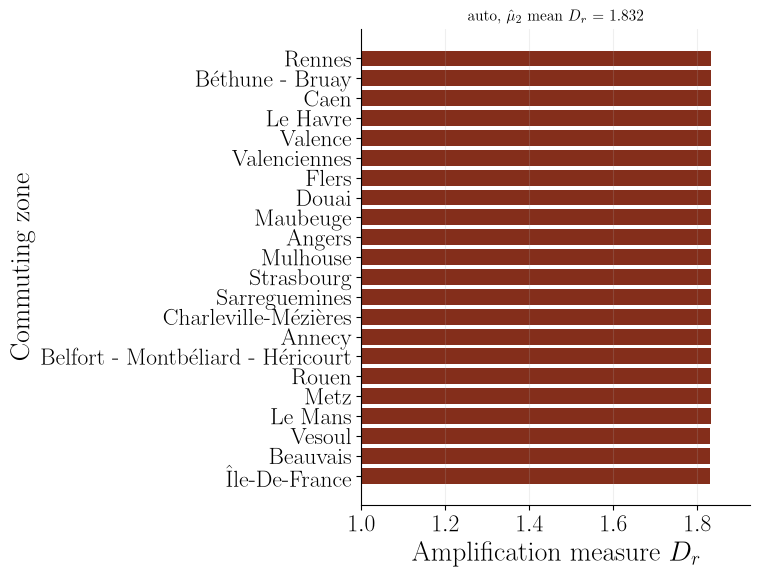


  mean D_r = 1.869 (one euro of demand -> 0.869 upstream), p90 = 1.875


,region,upstream_sales,amplification,supplier_cells,mean_upstream_distance,share_within_100km,share_within_200km
ze2010_downstream,,,,,,,
156,Brest,0.878,1.878,275,591.370,0.016,0.030
267,Cannes - Antibes,0.876,1.876,275,487.748,0.007,0.037
36,Le Havre,0.874,1.874,275,458.975,0.017,0.173
272,Marseille - Aubagne,0.872,1.872,275,389.163,0.039,0.079
273,Istres - Martigues,0.871,1.871,275,359.077,0.045,0.088
193,Bayonne,0.871,1.871,275,366.973,0.054,0.216
7,Roissy - Sud Picardie,0.870,1.870,275,379.472,0.178,0.328
137,Cholet,0.870,1.870,275,335.223,0.055,0.167
220,Valence,0.869,1.869,275,311.645,0.058,0.217


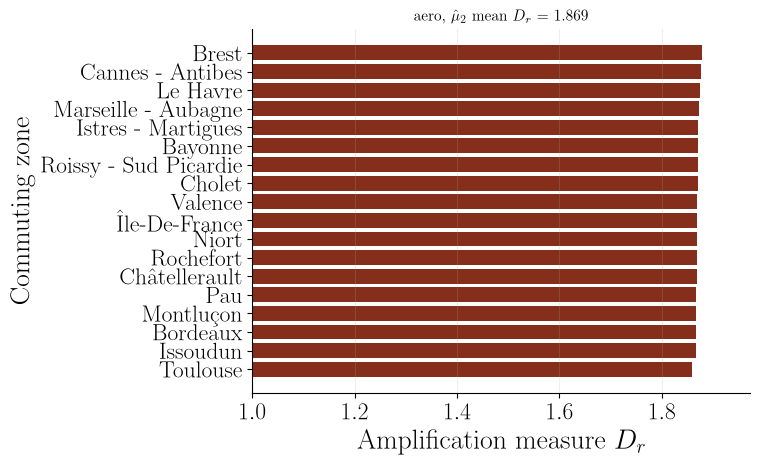

In [25]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    # the ESTIMATED economy, simulated from theta+ -- `reporting_data` caches,
    # so the sections share one solve rather than re-solving each
    data = reporting_data(industry, mu=MU, **RUN_KWARGS)["Both forces"]
    globals().update(data)


    diff = build_diffusion_frame(data)
    summ = amplification_summary(data, radii=AMPLIFICATION_RADII, diffusion=diff)
    print(f"\n  mean D_r = {summ['amplification'].mean():.3f} "
          f"(one euro of demand -> {summ['upstream_sales'].mean():.3f} upstream), "
          f"p90 = {summ['amplification'].quantile(0.9):.3f}")
    display(summ.round(3))

    plot_amplification(data, summary=summ,
                       save_to=f"{out_folder}/amplification_{industry}_mu{MU}.pdf")
    plt.show()


## Test 2 — is $D_r$ large? The input-output benchmark

Test 1 returns ~1.85. Whether that is a lot is not answerable from inside the model, so it is
read against the Leontief multipliers of the IO table.

**Two comparisons need no output data and come first**, because they are the ones that can be
made cleanly. The COMPOSITION of the downstream column — the $\pi_s$ object the $\Omega_s$
were calibrated on — against the model's simulated sector split; and the COVERAGE, the
modelled sectors' share of the industry's domestic intermediate purchases. Then
$(D_r - 1)/\text{coverage}$ is what the model implies for the downstream firm's TOTAL
intermediate share: a number that must sit below one and near $1 - \Omega_L$ to be credible.

**What the TES block cannot support, stated rather than papered over.** The technical
coefficients $a_{ij} = X_{ij}/x_j$ need GROSS OUTPUT, and the intermediate-flow block has no
value-added row, so each column must be normalised to an intermediate share supplied from
outside. Under a COMMON $m$ every column of $A$ sums to $m$, hence $\sum_i (A^k)_{ij} = m^k$
and the Leontief total is exactly $1/(1-m)$ for every sector — the cascade then measures the
assumption, not the network. The scalar path runs and says so loudly; pass a per-sector
`intermediate_share` for the informative answer.


[auto]  downstream industry C29A, TES from ../baseline_auto (dom), intermediate share m = 0.8448979386516853
  model  : mean D_r = 1.832  -> the modelled domestic sectors are 0.832 of downstream unit cost
  IO     : those sectors are 63.5% of the industry's DOMESTIC intermediate purchases (67.3% of dom + imp; the column is 59.0% domestic)
           => implied TOTAL intermediate share of unit cost = 1.311
           1 - aggregate labor share (the targeted moment) = 0.845
  NOTE: a COMMON intermediate share was used, so every sector's Leontief total is exactly 1/(1-m) = 6.447 and the cascade below measures that assumption, not the network. Pass a per-sector `intermediate_share` (value added / gross output) for an informative comparison.
  IO full  : round 1 = 1.845, two rounds = 2.559, Leontief total = 6.447   (model captures 15% of the aggregate, 99% of round 1)
  IO subset: round 1 = 1.845, two rounds = 2.559, Leontief total = 6.447   (model captures 15% of the aggregate, 99% of round

,n_sectors,round1,rounds_2,leontief_total,model_D_r,captured_of_aggregate,model_over_round1
support,,,,,,,
full,138,1.845,2.559,6.447,1.832,0.153,0.985
subset,10,1.845,2.559,6.447,1.832,0.153,0.985


,dom,imp,total,modelled,share_of_total,share_of_dom,pi_s_io,share_model
A129_1,,,,,,,,
C29A,1305.992,3491.482,4797.474,True,0.1602,0.0739,0.2380,0.2437
C29B,1264.404,1907.007,3171.411,True,0.1059,0.0715,0.1573,0.1534
G45Z,2368.608,0.000,2368.608,True,0.0791,0.1340,0.1175,0.1194
C28A,385.795,1799.754,2185.549,True,0.0730,0.0218,0.1084,0.1086
G46Z,1874.860,179.963,2054.823,True,0.0686,0.1060,0.1019,0.1022
C25D,1606.833,0.000,1606.833,True,0.0536,0.0909,0.0797,0.0762
C22B,841.858,514.752,1356.610,True,0.0453,0.0476,0.0673,0.0659
C33Z,1150.074,90.690,1240.764,True,0.0414,0.0650,0.0616,0.0638
M73Z,663.758,218.441,882.199,False,0.0295,0.0375,NaN,NaN


plot_io_benchmark: the cross-sector distribution is degenerate under a common intermediate share (every sector at 1/(1-m)). The figure still places the model, but the spread is an artefact — pass a per-sector `intermediate_share` for a real distribution.


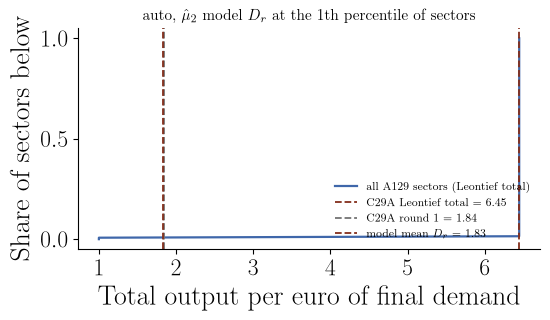

[aero]  downstream industry C30C, TES from ../baseline_aero (dom), intermediate share m = 0.8510782076751053
  model  : mean D_r = 1.869  -> the modelled domestic sectors are 0.869 of downstream unit cost
  IO     : those sectors are 72.3% of the industry's DOMESTIC intermediate purchases (80.5% of dom + imp; the column is 45.8% domestic)
           => implied TOTAL intermediate share of unit cost = 1.203
           1 - aggregate labor share (the targeted moment) = 0.851
  NOTE: a COMMON intermediate share was used, so every sector's Leontief total is exactly 1/(1-m) = 6.715 and the cascade below measures that assumption, not the network. Pass a per-sector `intermediate_share` (value added / gross output) for an informative comparison.
  IO full  : round 1 = 1.851, two rounds = 2.575, Leontief total = 6.715   (model captures 15% of the aggregate, 102% of round 1)
  IO subset: round 1 = 1.851, two rounds = 2.575, Leontief total = 6.715   (model captures 15% of the aggregate, 102% of rou

,n_sectors,round1,rounds_2,leontief_total,model_D_r,captured_of_aggregate,model_over_round1
support,,,,,,,
full,138,1.851,2.575,6.715,1.869,0.152,1.022
subset,10,1.851,2.575,6.715,1.869,0.152,1.022


,dom,imp,total,modelled,share_of_total,share_of_dom,pi_s_io,share_model
A129_1,,,,,,,,
C30C,6349.585,16899.867,23249.452,True,0.4979,0.2972,0.6184,0.6301
C33Z,4340.815,342.295,4683.110,True,0.1003,0.2032,0.1246,0.1261
C26E,12.912,2563.343,2576.255,True,0.0552,0.0006,0.0685,0.0661
G46Z,2124.009,203.879,2327.888,True,0.0499,0.0994,0.0619,0.0588
C28A,269.091,1255.322,1524.413,True,0.0326,0.0126,0.0405,0.0297
N78Z,977.000,0.000,977.000,False,0.0209,0.0457,NaN,NaN
M70Z,828.542,55.679,884.221,True,0.0189,0.0388,0.0235,0.0200
M71Z,569.876,148.231,718.107,True,0.0154,0.0267,0.0191,0.0245
C27B,110.626,468.915,579.541,True,0.0124,0.0052,0.0154,0.0165


plot_io_benchmark: the cross-sector distribution is degenerate under a common intermediate share (every sector at 1/(1-m)). The figure still places the model, but the spread is an artefact — pass a per-sector `intermediate_share` for a real distribution.


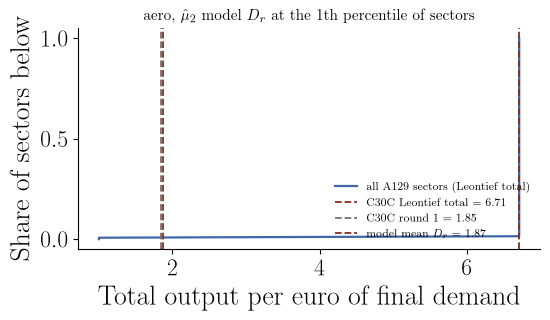

In [26]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    # the ESTIMATED economy, simulated from theta+ -- `reporting_data` caches,
    # so the sections share one solve rather than re-solving each
    data = reporting_data(industry, mu=MU, **RUN_KWARGS)["Both forces"]
    globals().update(data)

    # Guarded: without TES_dom.csv / TES_imp.csv beside the run this prints a note
    # instead of breaking the test.
    try:
        summ = amplification_summary(data, radii=AMPLIFICATION_RADII)
        bench = io_amplification_benchmark(data, summary=summ)
        display(bench.round(3))
        display(io_downstream_column(data).head(15).round(4))
        plot_io_benchmark(data, benchmark=bench,
                          save_to=f"{out_folder}/io_benchmark_{industry}_mu{MU}.pdf")
        plt.show()
    except FileNotFoundError as e:
        print(f"  IO benchmark skipped: {e}")


## Test 3 — how far does the response travel?

Amplification says how large the response is, not where it lands. The first incidence
statistic is the distance the euro covers:

$$d_r = \frac{\sum_{r'} X_{r'r}\, d_{r'r}}{\sum_{r'} X_{r'r}}.$$

One number in kilometres, aggregating the whole geography of the response rather than one
radius, and the object the alignment identity of §4 governs directly.

**Two things this test does NOT settle, and says so.** The LEVEL identifies nothing on its
own: ~350 km in both industries, which is neither which force is holding the euro there nor
whether the two industries hold it there for the same reason. That is test 4. And the
cross-buyer DISPERSION of $d_r$ is partly the shape of the country — a buyer in Brest faces a
larger $d_r$ than one in Bourges under *any* allocation — which is what
`distance_normalisation` removes by dividing through the uniform-allocation distance,
anchoring the statistic at one.

Both the CDF and the histogram are drawn. The CDF is the better object for a SHIFT (the
horizontal gap between two curves is the effect at every quantile, and it uses every point
exactly); the histogram is the better object for a SHAPE. With only ~20 shocked regions the
histogram is sensitive to `bins` in a way the CDF is not — vary `bins` before believing a mode.


[auto, mu = 2]  d_r: mean 349.5 km, median 360.1, min 262.4, max 418.7
  d_r normalised by the uniform-allocation distance (1 = as far as an unselective allocation would send it):
                              mean    50%    min    max
regime                                                 
Realised                     0.805  0.787  0.700  1.089
Both forces                  0.806  0.787  0.699  1.091
Equal comparative advantage  0.951  0.952  0.937  0.959
No trade cost                0.850  0.834  0.759  1.138


region  \
ze2010_downstream regime                                              
12                Realised                            Île-De-France   
                  Both forces                         Île-De-France   
                  Equal comparative advantage         Île-De-France   
                  No trade cost                       Île-De-France   
13                Realised                     Charleville-Mézières   
...                                                             ...   
220               No trade cost                             Valence   
230               Realised                                   Annecy   
                  Both forces                                Annecy   
                  Equal comparative advantage                Annecy   
                  No trade cost                              Annecy   

                                               mean_upstream_distance  \
ze2010_downstream regime                                                
12                Realised                                    262.440   
                  Both forces                                 262.262   
                  Equal comparative advantage                 355.388   
                  No trade cost                               284.581   
13                Realised                                    336.489   
...                                                               ...   
220               No trade cost                               380.441   
230               Realised                                    338.252   
                  Both forces                                 339.158   
                  Equal comparative advantage                 332.294   
                  No trade cost                               357.273   

                                               uniform_distance  \
ze2010_downstream regime                                          
12                Realised                              375.079   
                  Both forces                           375.079   
                  Equal comparative advantage           375.079   
                  No trade cost                         375.079   
13                Realised                              461.571   
...                                                         ...   
220               No trade cost                         334.369   
230               Realised                              352.927   
                  Both forces                           352.927   
                  Equal comparative advantage           352.927   
                  No trade cost                         352.927   

                                               distance_ratio  
ze2010_downstream regime                                       
12                Realised                              0.700  
                  Both forces                           0.699  
                  Equal comparative advantage           0.948  
                  No trade cost                         0.759  
13                Realised                              0.729  
...                                                       ...  
220               No trade cost                         1.138  
230               Realised                              0.958  
                  Both forces                           0.961  
                  Equal comparative advantage           0.942  
                  No trade cost                         1.012  

[88 rows x 4 columns]

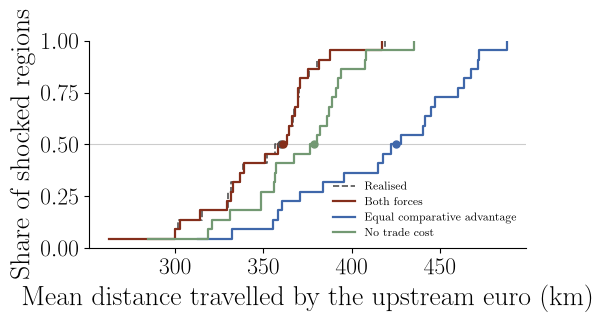

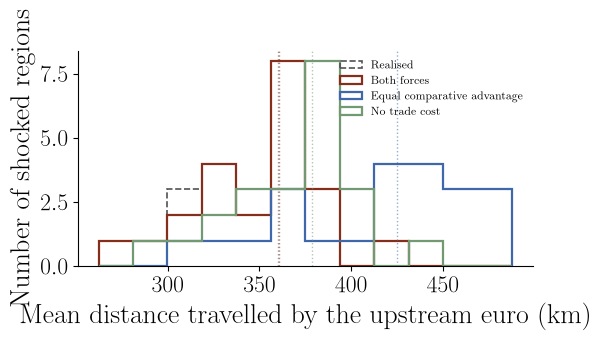

[aero, mu = 2]  d_r: mean 348.4 km, median 323.4, min 221.4, max 591.4
  d_r normalised by the uniform-allocation distance (1 = as far as an unselective allocation would send it):
                              mean    50%    min    max
regime                                                 
Realised                     0.877  0.919  0.581  0.988
Both forces                  0.877  0.919  0.583  0.990
Equal comparative advantage  0.882  0.889  0.824  0.944
No trade cost                0.964  0.984  0.750  1.129


region  \
ze2010_downstream regime                                               
7                 Realised                     Roissy - Sud Picardie   
                  Both forces                  Roissy - Sud Picardie   
                  Equal comparative advantage  Roissy - Sud Picardie   
                  No trade cost                Roissy - Sud Picardie   
11                Realised                                  Toulouse   
...                                                              ...   
272               No trade cost                  Marseille - Aubagne   
273               Realised                        Istres - Martigues   
                  Both forces                     Istres - Martigues   
                  Equal comparative advantage     Istres - Martigues   
                  No trade cost                   Istres - Martigues   

                                               mean_upstream_distance  \
ze2010_downstream regime                                                
7                 Realised                                    379.472   
                  Both forces                                 379.630   
                  Equal comparative advantage                 334.867   
                  No trade cost                               438.324   
11                Realised                                    221.443   
...                                                               ...   
272               No trade cost                               424.811   
273               Realised                                    359.077   
                  Both forces                                 359.818   
                  Equal comparative advantage                 375.279   
                  No trade cost                               395.415   

                                               uniform_distance  \
ze2010_downstream regime                                          
7                 Realised                              388.088   
                  Both forces                           388.088   
                  Equal comparative advantage           388.088   
                  No trade cost                         388.088   
11                Realised                              381.076   
...                                                         ...   
272               No trade cost                         445.676   
273               Realised                              421.939   
                  Both forces                           421.939   
                  Equal comparative advantage           421.939   
                  No trade cost                         421.939   

                                               distance_ratio  
ze2010_downstream regime                                       
7                 Realised                              0.978  
                  Both forces                           0.978  
                  Equal comparative advantage           0.863  
                  No trade cost                         1.129  
11                Realised                              0.581  
...                                                       ...  
272               No trade cost                         0.953  
273               Realised                              0.851  
                  Both forces                           0.853  
                  Equal comparative advantage           0.889  
                  No trade cost                         0.937  

[72 rows x 4 columns]

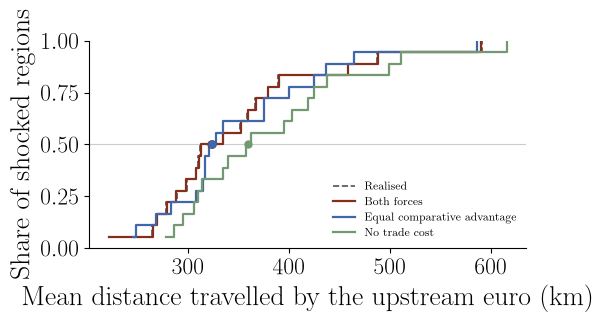

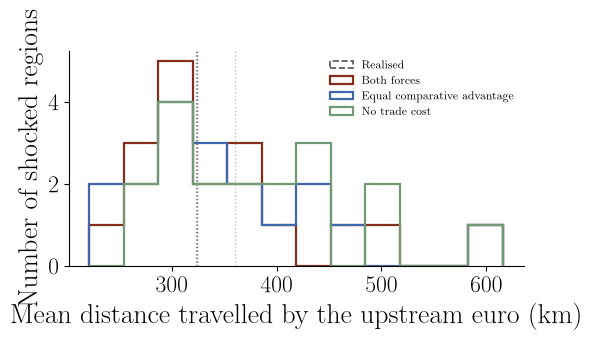

In [27]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    # the ESTIMATED economy, simulated from theta+ -- `reporting_data` caches,
    # so the sections share one solve rather than re-solving each
    data = reporting_data(industry, mu=MU, **RUN_KWARGS)["Both forces"]
    globals().update(data)

    diff = build_diffusion_frame(data)
    summ = amplification_summary(data, radii=AMPLIFICATION_RADII, diffusion=diff)
    print(f"[{industry}, mu = {MU}]  d_r: mean {summ['mean_upstream_distance'].mean():.1f} km, "
          f"median {summ['mean_upstream_distance'].median():.1f}, "
          f"min {summ['mean_upstream_distance'].min():.1f}, "
          f"max {summ['mean_upstream_distance'].max():.1f}")

    # d_r purged of the country's shape: 1 = as far as an unselective allocation sends it
    display(distance_normalisation(data, diffusion=diff).round(3))

    plot_distance_distribution(data, diffusion=diff,
                               save_to=f"{out_folder}/counterfactual_distance_{industry}_mu{MU}.pdf")
    plt.show()
    plot_distance_histogram(data, diffusion=diff,
                            save_to=f"{out_folder}/counterfactual_distance_hist_{industry}_mu{MU}.pdf")
    plt.show()


## Test 3 bis — how uniform is the force that sets that distance?

Test 3 reports where $d_r$ ends up. This one reports the *rate* that puts it there, which is
the object the next test integrates. By the alignment identity, dialling comparative
advantage down moves a buyer's average sourcing distance at

$$\frac{\partial \bar d_{rs}}{\partial t} = \operatorname{Cov}_{\rho_{\cdot rs}}\!\big(\log \hat T_{a(l)s},\, d_{lr}\big),$$

taken across the cells competing for that buyer and weighted by the sourcing probabilities.
It is in KILOMETRES per log point, so unlike the correlation of the section above it can be
read against the counterfactual directly: a buyer's whole displacement under *Equal comparative advantage*
is the path integral of its own covariance.

**Why this figure and not the correlation, and why both are kept.** The correlation is
scale-free, which is what makes it the right object in §4 — $\hat T$ is identified only up to
a per-sector scale, so a comparison of two industries has to be. But a scale-free statistic
carries no distance, and §5.1 quotes kilometres. Reporting the covariance here is what lets
the counterfactual paragraph and the figure it cites be the same statistic.

**What the figure answers that a median cannot.** A sector median of $-54$ km is consistent
with every buyer facing the same mild alignment *and* with half facing a strong one and half
the opposite — different economies, different counterfactuals. The mass on either side of
zero is the answer: where it is one-sided, equalising $\hat T$ moves every buyer the same way
and the aggregate is the buyer; where it straddles zero, the aggregate is a cancellation and
the buyer-level picture of test 4 is the one to read.

The histogram and a Gaussian kernel density are drawn together. The density is the cleaner
object for a paper, but it is an estimate with a bandwidth: at a couple of hundred pairs it
can put a shoulder where the data have three points, and it leaks a little mass past the
extreme observations. The outline underneath is the raw count to check it against — vary `bw`
as `bins` is varied on the histogram of test 3. `level="buyer"` spend-aggregates across
sectors, which is the level at which "negative for every buyer" is a claim rather than a
statement about (sector, buyer) pairs.


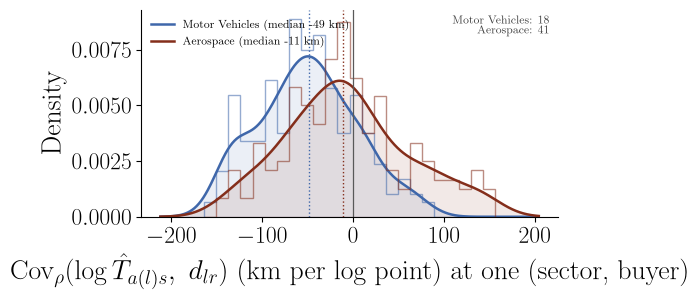

Motor Vehicles: 220 (sector, buyer) pairs, median -48.7 km/log pt, purchase-weighted mean -61.5, 18.2% positive, p10 -127.0, p90 +18.8
    Cov(log d, d) > 0 for 100.0% of pairs (must be 100%), median +99.6 km/log pt
Aerospace: 180 (sector, buyer) pairs, median -10.9 km/log pt, purchase-weighted mean -16.3, 40.6% positive, p10 -92.4, p90 +95.3
    Cov(log d, d) > 0 for 100.0% of pairs (must be 100%), median +87.1 km/log pt


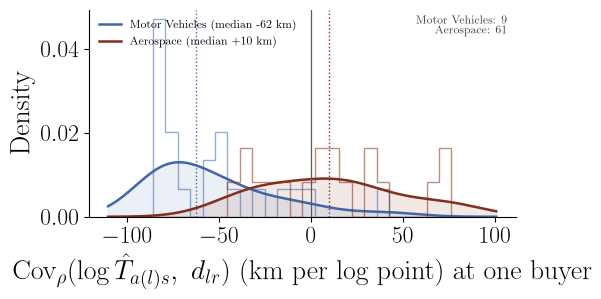

Motor Vehicles: 22 buyers, median -62.2 km/log pt, 9.1% positive, range [-85.8, +40.0]
Aerospace: 18 buyers, median +9.8 km/log pt, 61.1% positive, range [-44.1, +76.6]


In [28]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
cov_data = []
for cfg in INDUSTRIES:
    data = reporting_data(cfg["industry"], mu=MU, **RUN_KWARGS)["Both forces"]
    cov_data.append(data)

_cov_ax, _cov_frames = plot_alignment_covariance(
    [(cfg["display_name"], d) for cfg, d in zip(INDUSTRIES, cov_data)],
    save_to=f"{out_folder}/alignment_covariance_mu{MU}.pdf")
plt.show()

for _name, _fr in _cov_frames.items():
    _w, _c = _fr["buyer_weight"], _fr["cov_T_d_km"]
    print(f"{_name}: {len(_fr)} (sector, buyer) pairs, median {_c.median():+.1f} km/log pt, "
          f"purchase-weighted mean {float((_c * _w).sum() / _w.sum()):+.1f}, "
          f"{float((_c > 0).mean()):.1%} positive, "
          f"p10 {_c.quantile(0.10):+.1f}, p90 {_c.quantile(0.90):+.1f}")
    # the trade-cost rate: Cov(log d, d) is a covariance between two increasing functions
    # of the same variable, so this line gates the arithmetic rather than reporting a result
    print(f"    Cov(log d, d) > 0 for {float((_fr['cov_d_d_km'] > 0).mean()):.1%} of pairs "
          f"(must be 100%), median {_fr['cov_d_d_km'].median():+.1f} km/log pt")

# --- and the same covariance at the BUYER level, which is what 5.1 asserts ----
# One sector can carry most of a buyer's spending, so the pair median and the buyer
# median need not agree; this is the spend-weighted aggregation, the one the euros get.
try:
    plot_alignment_covariance(
        [(cfg["display_name"], d) for cfg, d in zip(INDUSTRIES, cov_data)],
        level="buyer",
        save_to=f"{out_folder}/alignment_covariance_buyer_mu{MU}.pdf")
    plt.show()
    for cfg, d in zip(INDUSTRIES, cov_data):
        v = alignment_covariance_by_buyer(d)["cov_T_d_km"].dropna()
        print(f"{cfg['display_name']}: {len(v)} buyers, median {v.median():+.1f} km/log pt, "
              f"{float((v > 0).mean()):.1%} positive, "
              f"range [{v.min():+.1f}, {v.max():+.1f}]")
except (FileNotFoundError, NameError) as e:
    print(f"  buyer-level aggregation skipped: {e}")


## Test 4 — which force keeps the euro close?

The sourcing probabilities are closed form, so the same shock can be propagated with either
allocative force switched off. What is held FIXED is what the model makes a cost-share object
— how much of the euro leaves for upstream, and how it splits across SECTORS, neither of which
involves $T$ or $\alpha$. What moves is where inside a sector the euro lands.

**Two consequences, both load-bearing.** Since $\sum_l \rho_{lrs} = 1$ for every (sector,
buyer), $D_r$ is IDENTICAL under every regime: cancelling a channel moves a shock in space
without changing its size. That is why every counterfactual figure is about incidence and none
re-draws $D_r$, and it is gated to machine precision. And `Both forces` is the closed-form
EXPECTATION of the allocation while the parquet is one realised finite-variety draw of it, so
the two differ by granularity — the gap is printed, and the closed-form row, not the realised
one, is the baseline the other regimes are read against.

**The two regimes are not symmetric interventions.** Equalising $\hat T$ removes a
*supplier*-specific term; setting $\alpha = 0$ removes the *only buyer-specific* term in
$\rho_{lrs} \propto T_{a(l)s} d_{lr}^{-\theta\alpha}$. Any statistic measuring how much of its
own position a buyer's sourcing inherits must therefore go to zero under $\alpha = 0$ by
construction — that regime is an internal control on such a statistic, not an economic
counterfactual to be compared with the other.

By the alignment identity the movement of $d_r$ IS the co-location covariance evaluated at
that buyer, so the SHAPE of the shift is informative in a way its mean is not: a block shift
means the covariance is common across buyers, crossing curves mean the sign is not.


  [counterfactual] D_r RANGES 0.0496 across regimes: these frames come from re-solved economies, so the intermediate expenditure share has responded
  [counterfactual] and matches the realised D_r to 0.00e+00
  [counterfactual] share_within_100km: realised 0.071 vs closed-form both-forces 0.071 — the gap is granularity, not a different economy

[auto, mu = 2]  the shock with one force switched off:
                             amplification  mean_upstream_distance  share_within_100km  weighted_share_within_100km  share_within_200km  weighted_share_within_200km
regime                                                                                                                                                              
Realised                             1.832                 349.581               0.071                        0.071               0.234                        0.234
Both forces                          1.832                 349.581               0.071                 

,mean_upstream_distance,share_within_100km,share_within_200km,mean_upstream_distance_geography,mean_upstream_distance_mix,share_within_100km_geography,share_within_100km_mix,share_within_200km_geography,share_within_200km_mix,amplification
regime,,,,,,,,,,
Both forces,349.6237,0.0709,0.2342,349.6237,349.6237,0.0709,0.0709,0.2342,0.2342,1.8323
Equal comparative advantage,414.9943,0.0594,0.1770,415.9108,352.6230,0.0592,0.0723,0.1761,0.2348,1.7913
No trade cost,368.4827,0.0525,0.1980,369.0124,349.0746,0.0521,0.0714,0.1970,0.2353,1.7843



  the distribution of d_r behind that mean, and how each force shifts it:
                                              p10     p25     p50     p75     p90  n_regions  share_moved_lt_5km  share_moved_away
Realised                                   303.10  330.65  360.11  369.99  379.72         22                1.00              0.00
Both forces                                303.10  330.65  360.11  369.99  379.72         22                1.00              0.00
Equal comparative advantage                353.91  371.12  424.33  456.52  469.95         22                0.05              0.91
No trade cost                              321.71  350.29  377.10  390.01  404.87         22                0.00              1.00
Realised - Both forces                       0.00    0.00    0.00    0.00    0.00         22                1.00              0.00
Equal comparative advantage - Both forces   50.80   40.47   64.23   86.54   90.24         22                0.05              0.91
No trade

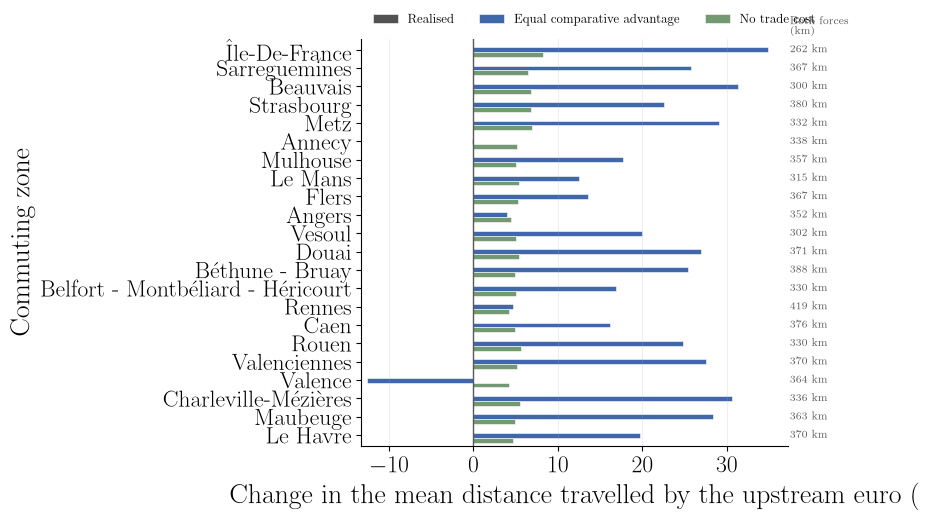

  [counterfactual] D_r RANGES 0.1163 across regimes: these frames come from re-solved economies, so the intermediate expenditure share has responded
  [counterfactual] and matches the realised D_r to 0.00e+00
  [counterfactual] share_within_100km: realised 0.093 vs closed-form both-forces 0.093 — the gap is granularity, not a different economy

[aero, mu = 2]  the shock with one force switched off:
                             amplification  mean_upstream_distance  share_within_100km  weighted_share_within_100km  share_within_200km  weighted_share_within_200km
regime                                                                                                                                                              
Realised                             1.869                 348.832               0.093                        0.093               0.219                        0.218
Both forces                          1.869                 348.832               0.093                 

,mean_upstream_distance,share_within_100km,share_within_200km,mean_upstream_distance_geography,mean_upstream_distance_mix,share_within_100km_geography,share_within_100km_mix,share_within_200km_geography,share_within_200km_mix,amplification
regime,,,,,,,,,,
Both forces,348.7579,0.0929,0.2186,348.7579,348.7579,0.0929,0.0929,0.2186,0.2186,1.8694
Equal comparative advantage,354.8956,0.1030,0.2464,352.7512,348.9823,0.1052,0.0948,0.2490,0.2232,1.8172
No trade cost,379.2243,0.0520,0.1573,382.8464,345.0158,0.0496,0.0965,0.1514,0.2253,1.7621



  the distribution of d_r behind that mean, and how each force shifts it:
                                              p10     p25     p50     p75     p90  n_regions  share_moved_lt_5km  share_moved_away
Realised                                   267.80  291.32  323.43  376.35  467.61         18                1.00              0.00
Both forces                                267.80  291.32  323.43  376.35  467.61         18                1.00              0.00
Equal comparative advantage                266.67  313.35  328.72  392.12  446.89         18                0.06              0.44
No trade cost                              287.82  306.73  354.64  420.62  499.48         18                0.00              1.00
Realised - Both forces                       0.00    0.00    0.00    0.00    0.00         18                1.00              0.00
Equal comparative advantage - Both forces   -1.13   22.03    5.29   15.78  -20.71         18                0.06              0.44
No trade

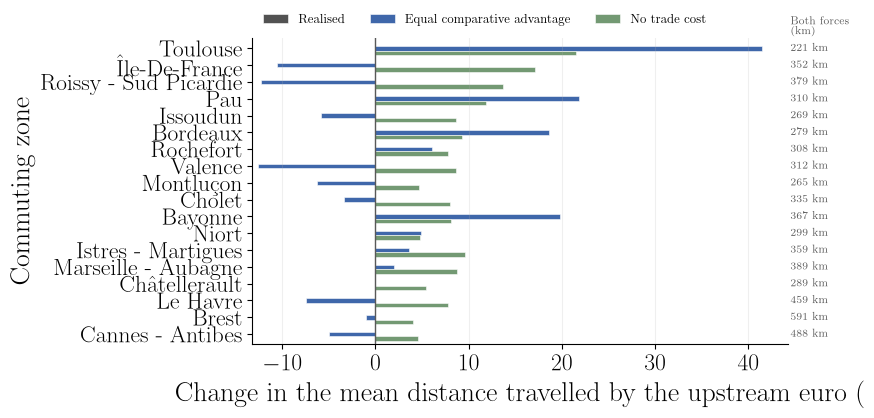

In [29]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    # the ESTIMATED economy, simulated from theta+ -- `reporting_data` caches,
    # so the sections share one solve rather than re-solving each
    data = reporting_data(industry, mu=MU, **RUN_KWARGS)["Both forces"]
    globals().update(data)

    econ   = reporting_data(industry, mu=MU, **RUN_KWARGS)
    diff   = build_diffusion_frame(data)
    # The frames come from the RE-SOLVED economies, not from reallocating the estimated
    # economy's spend: equalising comparative advantage makes sourcing less efficient,
    # raises P_r, and with lambda < 1 (labour and intermediates COMPLEMENTS) raises the
    # share of the euro spent upstream at all. That response is part of how comparative
    # advantage governs amplification and is not something to hold fixed.
    frames = simulated_frames(econ)
    det    = counterfactual_amplification(data, radii=AMPLIFICATION_RADII,
                                          frames=frames, diffusion=diff)

    print(f"\n[{industry}, mu = {MU}]  the shock with one force switched off:")
    print(counterfactual_summary(data, radii=AMPLIFICATION_RADII, detail=det).round(3).to_string())

    # ... and the same thing split into its three EXACT channels. The model factorises
    #     X_lr = (D_r - 1) * sum_s theta_rs * rho_lrs,
    # so D_r moves through the LEVEL channel alone (how much leaves for upstream), while
    # L_r(d) and d_r are ratios in which (D_r - 1) cancels and move through the sector
    # MIX and the within-sector GEOGRAPHY alone. `counterfactual_frames` is the geography
    # channel on its own; it is kept as a decomposition, not as the answer.
    print()
    dec = amplification_decomposition(econ, radii=AMPLIFICATION_RADII)
    display(dec.groupby(level="regime", observed=True).mean(numeric_only=True).round(4))

    # is the shift a block translation or a rotation? the quantile-by-quantile answer
    print("\n  the distribution of d_r behind that mean, and how each force shifts it:")
    print(distance_distribution_report(data, detail=det).to_string())

    # ... and the same thing differenced BUYER BY BUYER rather than quantile by quantile,
    # on the percentage scale `plot_counterfactual_distance` is drawn on. `mean_abs_pct`
    # against `mean_pct` is the size of the reallocation a near-zero average hides.
    print("\n  each buyer's d_r as a % deviation from the estimated allocation:")
    rel = relative_displacement(data, detail=det)
    print(rel.to_string())
    # every buyer, sorted: there are only ~20 of them, and the paper names individual
    # commuting zones, so the full list is what a named claim has to be checked against.
    _p = rel.attrs["per_buyer_pct"]
    for _reg in [c for c in ("Equal comparative advantage", "No trade cost") if c in _p.columns]:
        print(f"\n  {_reg}: each buyer's % deviation, sorted (negative = sources closer):")
        print(_p[_reg].sort_values(ascending=False).round(1).to_string())

    plot_counterfactual_distance(
        data, detail=det,
        save_to=f"{out_folder}/counterfactual_distance_region_{industry}_mu{MU}.pdf")
    plt.show()


## Test 5 — where does the response land?

Test 4 says capability sits near demand in motor vehicles. It does not say whether that
capability is one broad mass inside the demand distribution, a set of local pockets, or a
small number of hubs — three different economies, and only the third is hub-and-spoke.

**The barycentre cannot make that distinction, and this is a defect rather than a taste.**
It is the FIRST MOMENT of the destination distribution, and a dispersed central pool and a
pair of distant hubs have nearly the same first moment: both sit near the national centre of
mass, since with four fifths of the euros spread nationally the mean is pinned there however
concentrated the remaining fifth is. That is exactly why every aerospace arrow lands in the
Massif Central while the euros are collected by Toulouse and Île-de-France. The shrinkage
coefficient $\lambda$ inherits the degeneracy — below 0.12 in both industries, separating
nothing. `barycentre_shrinkage` is still run below, as a reported robustness exhibit.

The object with the answer is the incidence vector $\omega_r = (X_{lr}/\sum_l X_{lr})_l$,
characterised by two numbers. CONCENTRATION is the effective number of destinations
$1/H_r$, reported RELATIVE to the uniform allocation because its level is mostly the sector's
cell count and the shape of the country. COMMONALITY is the euro share that is buyer-specific,
$\Delta_r = \tfrac12\sum_l|\omega_{lr} - \bar\omega_l|$, read against ZERO rather than against
a benchmark — the allocation is already nearly buyer-independent, so an overlap statistic in
levels sits at its ceiling in both industries.

The prediction is stated before the numbers: aerospace should be concentrated AND common
(bottom-left of the plane), motor vehicles spread and common.



[auto, mu = 2]
  the incidence vector: how concentrated, and how much is buyer-specific
  (n_eff_ratio < 1 = the forces concentrate; tv_common is the euro share that is buyer-specific, read against 0)
                               n_eff  n_eff_ratio    hhi   top3  own_share  tv_common  cos_common  pairwise_cos  pairwise_tv
regime                                                                                                                      
Realised                     108.883        0.481  0.009  0.072      0.005      0.038       0.997         0.992        0.051
Both forces                  108.883        0.481  0.009  0.072      0.005      0.038       0.997         0.992        0.051
Equal comparative advantage  228.586        1.011  0.004  0.023      0.005      0.031       0.996         0.990        0.047
No trade cost                114.818        0.508  0.009  0.067      0.003      0.000       1.000         1.000        0.000
Uniform benchmark            226.140        1.00

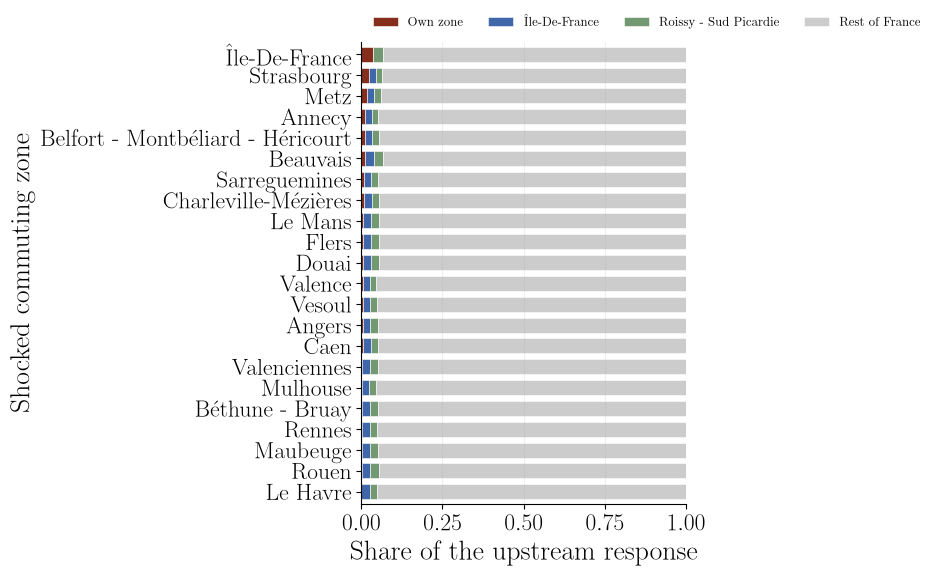


[aero, mu = 2]
  the incidence vector: how concentrated, and how much is buyer-specific
  (n_eff_ratio < 1 = the forces concentrate; tv_common is the euro share that is buyer-specific, read against 0)
                              n_eff  n_eff_ratio    hhi   top3  own_share  tv_common  cos_common  pairwise_cos  pairwise_tv
regime                                                                                                                     
Realised                     27.549        0.328  0.036  0.220      0.010      0.077       0.990         0.971        0.119
Both forces                  27.549        0.328  0.036  0.220      0.010      0.077       0.990         0.971        0.119
Equal comparative advantage  86.136        0.991  0.012  0.085      0.009      0.105       0.956         0.873        0.158
No trade cost                26.850        0.313  0.037  0.224      0.003      0.000       1.000         1.000        0.000
Uniform benchmark            85.802        1.000  0.01

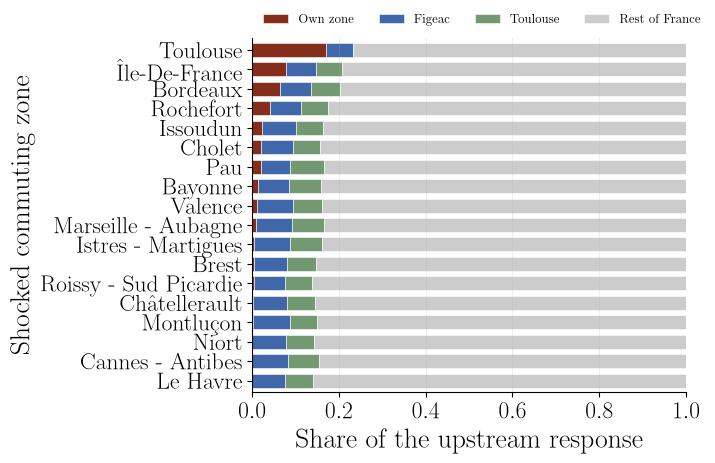

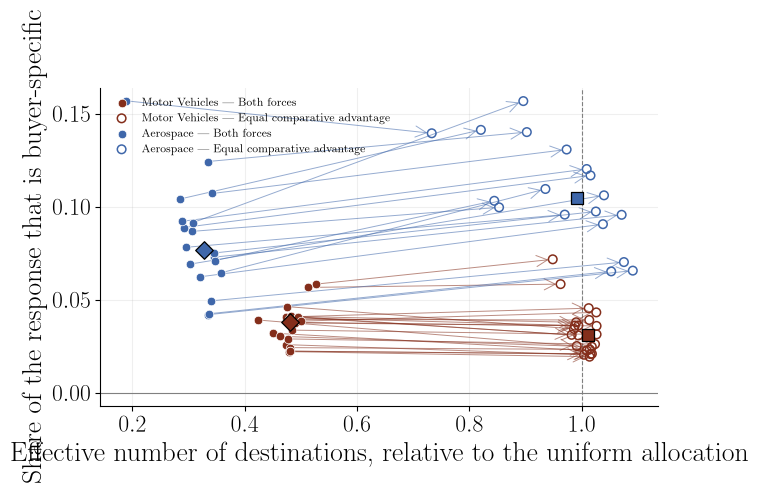

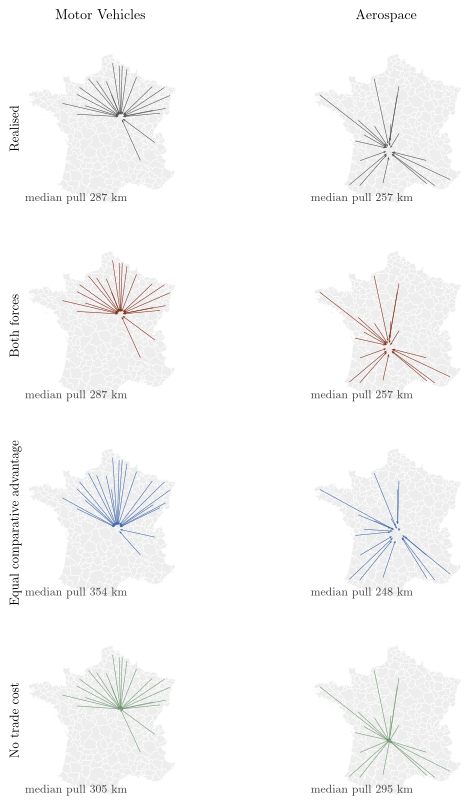

                                            slope     se       t  ci_lo  ci_hi  slope_x  slope_y     r2  dispersion_ratio  median_pull_km  median_distance_km     n
industry       regime                                                                                                                                              
Aerospace      Both forces                  0.091  0.012   7.541  0.067  0.114    0.059    0.117  0.803             0.101         256.869             327.105  18.0
               Equal comparative advantage  0.124  0.015   8.449  0.096  0.153    0.114    0.133  0.860             0.134         247.896             323.458  18.0
               No trade cost               -0.011  0.004  -3.194 -0.018 -0.004   -0.001   -0.020  0.361             0.019         294.860             361.873  18.0
               Realised                     0.091  0.012   7.472  0.067  0.115    0.059    0.117  0.801             0.101         256.939             326.821  18.0
Motor Vehicles B

slope     se       t  ci_lo  \
industry       regime                                                     
Aerospace      Both forces                  0.091  0.012   7.541  0.067   
               Equal comparative advantage  0.124  0.015   8.449  0.096   
               No trade cost               -0.011  0.004  -3.194 -0.018   
               Realised                     0.091  0.012   7.472  0.067   
Motor Vehicles Both forces                  0.056  0.002  34.327  0.053   
               Equal comparative advantage  0.058  0.003  19.386  0.052   
               No trade cost               -0.001  0.000 -12.464 -0.001   
               Realised                     0.056  0.002  33.627  0.053   

                                            ci_hi  slope_x  slope_y     r2  \
industry       regime                                                        
Aerospace      Both forces                  0.114    0.059    0.117  0.803   
               Equal comparative advantage  0.153    0.114    0.133  0.860   
               No trade cost               -0.004   -0.001   -0.020  0.361   
               Realised                     0.115    0.059    0.117  0.801   
Motor Vehicles Both forces                  0.059    0.058    0.053  0.961   
               Equal comparative advantage  0.064    0.056    0.062  0.956   
               No trade cost               -0.001   -0.001   -0.001  0.840   
               Realised                     0.060    0.058    0.053  0.960   

                                            dispersion_ratio  median_pull_km  \
industry       regime                                                          
Aerospace      Both forces                             0.101         256.869   
               Equal comparative advantage             0.134         247.896   
               No trade cost                           0.019         294.860   
               Realised                                0.101         256.939   
Motor Vehicles Both forces                             0.057         287.498   
               Equal comparative advantage             0.059         354.181   
               No trade cost                           0.001         304.873   
               Realised                                0.058         286.539   

                                            median_distance_km     n  
industry       regime                                                 
Aerospace      Both forces                             327.105  18.0  
               Equal comparative advantage             323.458  18.0  
               No trade cost                           361.873  18.0  
               Realised                                326.821  18.0  
Motor Vehicles Both forces                             353.971  22.0  
               Equal comparative advantage             422.301  22.0  
               No trade cost                           372.228  22.0  
               Realised                                353.364  22.0

,a,b,diff,se,t,ci_lo,ci_hi
0,Aerospace / Equal comparative advantage,Aerospace / Both forces,0.034,0.019,1.767,-0.004,0.071
1,Aerospace / No trade cost,Aerospace / Both forces,-0.102,0.013,-8.138,-0.127,-0.078
2,Aerospace / Realised,Aerospace / Both forces,-0.000,0.017,-0.003,-0.034,0.033
3,Motor Vehicles / Equal comparative advantage,Motor Vehicles / Both forces,0.002,0.003,0.530,-0.005,0.009
4,Motor Vehicles / No trade cost,Motor Vehicles / Both forces,-0.058,0.002,-35.043,-0.061,-0.054
5,Motor Vehicles / Realised,Motor Vehicles / Both forces,0.000,0.002,0.062,-0.004,0.005
6,Motor Vehicles / Both forces,Aerospace / Both forces,-0.035,0.012,-2.845,-0.058,-0.011



Motor Vehicles — where the arrows point (realised economy):


,hub_index,n_regions,sales,share_of_regions
hub,,,,
Cosne - Clamecy,3,14,11.654,0.636



Aerospace — where the arrows point (realised economy):


,hub_index,n_regions,sales,share_of_regions
hub,,,,
Tulle,209,5,4.354,0.278
Brive-La-Gaillarde,8,3,2.596,0.167
Guéret,211,2,1.739,0.111
Ussel,210,1,0.867,0.056


In [30]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
incidence_tables, panel_data = [], []
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    # the ESTIMATED economy, simulated from theta+ -- `reporting_data` caches,
    # so the sections share one solve rather than re-solving each
    data = reporting_data(industry, mu=MU, **RUN_KWARGS)["Both forces"]
    panel_data.append(data)
    globals().update(data)

    diff   = build_diffusion_frame(data)
    # the re-solved economies, so the sector MIX responds: the incidence vector is
    # normalised per buyer, so the level channel cancels out of it, but the mix does not
    # -- sectors differ in geography, so reallocating across them moves where the euro
    # lands even at an unchanged within-sector allocation.
    frames = simulated_frames(reporting_data(industry, mu=MU, **RUN_KWARGS))

    print(f"\n[{industry}, mu = {MU}]")
    inc = incidence_concentration_overlap(data, frames=frames, diffusion=diff)
    incidence_tables.append((cfg["display_name"], inc))
    incidence_summary(inc)

    # the figure that replaces the barycentre arrows: own zone, the industry's hubs, rest
    plot_destination_composition(
        data, diffusion=diff,
        save_to=f"{out_folder}/destination_composition_{industry}_mu{MU}.pdf")
    plt.show()

# the 2x2 plane, both industries on one window
plot_incidence_plane(incidence_tables, save_to=f"{out_folder}/incidence_plane_mu{MU}.pdf")
plt.show()

# The barycentre, kept as a reported robustness exhibit rather than as the answer.
# Guarded: without france.gpkg (or geopandas) there is no geometry to place one in.
try:
    fig, barys = barycentre_panel(
        [(cfg["display_name"], d) for cfg, d in zip(INDUSTRIES, panel_data)],
        save_to=f"{out_folder}/sourcing_barycentre_panel_mu{MU}.pdf")
    plt.show()
    shrink = barycentre_shrinkage_report(barys)
    display(shrink.round(3))
    display(barycentre_shrinkage_contrast(shrink).round(3))
    for cfg, d in zip(INDUSTRIES, panel_data):
        print(f"\n{cfg['display_name']} — where the arrows point (realised economy):")
        display(barycentre_hubs(d).round(3))
except (FileNotFoundError, KeyError, ValueError) as e:
    print(f"  barycentre panel skipped: {type(e).__name__}: {e}")


## Test 5 bis — how few places, and are they the same places for every buyer?

The sourcing distance says how far a shock travels, not where it lands: a buyer sourcing
at 350 km may be drawing on a ring of neighbours or on a single distant hub, and the two
economies behave differently when the industry is shocked as a whole. Two further
questions settle it. **How many places does one buyer's shock reach?** And **do different
buyers' shocks reach the same places?** A hub serving every buyer aggregates the
industry's shocks; distinct pockets diversify them.

Both are answered by one statistic and one identity, taken **sector by sector** — a
buyer's shock hits every input sector, and each sector has its own supplier geography, so
pooling them lets a nearly common input mix impose a similarity that says nothing about
where inside a sector the euro goes (this is why the pooled cosine of Test 5 sits above
0.97 and separates nothing). With buyer weights $\pi_{rs}$ (the share of sector $s$'s
purchases made by buyer $r$) and $\bar\omega_s = \sum_r \pi_{rs}\,\omega_{rs}$,

$$\bar H_s \;=\; \sum_r \pi_{rs} H_{rs} \;=\; \underbrace{H(\bar\omega_s)}_{\text{common}} \;+\; \underbrace{M_s}_{\text{buyer-specific}},\qquad M_s=\sum_l \mathrm{Var}_\pi(\omega_{lrs})\ \ge 0,\qquad C_s = 1-\frac{M_s}{\bar H_s}.$$

A shock to **one** buyer lands with concentration $H_{rs}$; a shock to the **whole
industry** lands with $H(\bar\omega_s)$. So $C_s$ is the share of a buyer's concentration
that aggregating across buyers cannot diversify away. Unlike the overlap statistics of
Test 5, this decomposes exactly, so the two halves add up and can be counted in euros.

The 2×2 keeps all four cells, and the fourth is not empty — low concentration with low
commonality is **diffuse local sourcing**, every buyer spreading over its own
neighbourhood, which is where the `Equal comparative advantage` regime sits.

|            | $H$ low        | $H$ high       |
|------------|----------------|----------------|
| $C$ high   | common pool    | hub-and-spoke  |
| $C$ low    | diffuse local  | local pockets  |

Three things this section does that the ones above do not.

**Spending weights, not medians.** The identity holds for a weighted mean over buyers and
for no other aggregator, so every average here is spend-weighted and the cross-buyer
distributions go to the appendix figure. And $H$ is averaged *before* it is inverted into
an effective number, since $1/H$ is convex.

**The forces enter as derivatives of $H$**, the exact analogue of the distance identity:
$\partial H_{rs}/\partial t = 2\,\mathrm{Cov}_\rho(\log T,\rho)$ and
$\partial H_{rs}/\partial(\alpha\theta) = -2\,\mathrm{Cov}_\rho(\log d,\rho)$ — same
weights, same two forces, but now covarying with the **shares** rather than with the
distance. Comparative advantage raises concentration whenever the productive cells
already hold large shares; trade costs raise it only if a buyer's large suppliers are the
nearby ones, and that sign is genuinely ambiguous. Distance is the *only* buyer-specific
term in $\rho$, so $C_s = 1$ **exactly** under $\alpha = 0$ — an internal control that is
an identity here, not the 0.003 the overlap table could offer.

**Granularity enters, and it did not enter the distance paragraph.** That is an argument
about the ORDER of the statistic, not about magnitudes: $d_r$ is linear in $\omega$ and
$E[\omega^{\text{realised}}]=\omega^{\text{expected}}$, so averaging was exact; $H$ is
quadratic, so $E[H] > H(E[\omega])$ strictly. With $N_s$ varieties each won by exactly one
cell,

$$E[H_{rs}] \;\approx\; H^{E}_{rs} + \frac{1-H^{E}_{rs}}{N_s},$$

exact when varieties carry equal expenditure shares. Two predictions follow, and the table
tests both: granularity and comparative advantage are **substitutes** as sources of
concentration (the added term is proportional to $1-H^E$, so it adds most where the
structure is diffuse), while granularity and distance are **complements** as sources of
buyer-specificity (chance winners differ across buyers only in so far as the buyers are
far enough apart to rank cells differently at all). Taking expectations of the identity
splits $E[\bar H_s]$ into four additive cells — structural common, structural
buyer-specific, granular common, granular buyer-specific — which is the figure. The two
granular cells are **untargeted**: bilateral links are not observed, so they are
predictions of the model.

One definitional care. "Structural" here means the **expected network** $E[\omega]$, not
the win probabilities $\tilde\gamma$: $\rho$ is the probability a cell wins a variety,
$\omega$ the share of the euro it collects, and under CES a cheaper winner takes a larger
value share. `expected_network_check` measures the gap rather than assuming it away.


[auto, mu = 2] — where the response lands
  concentration and commonality, sector by sector (spend-weighted over buyers)
                                   sector_name  n_cells  spend  h_bar  h_common    m      C    n_eff  n_eff_common  n_hat_s  n_eff_ratio
regime                      sector                                                                                                      
Both forces                 0             C22A      113  0.661  0.017     0.017  0.0  0.979   58.509        59.742     25.0        0.518
                            1             C22B      200  1.206  0.008     0.008  0.0  0.985  120.414       122.279     22.0        0.602
                            2             C24A       69  0.562  0.021     0.021  0.0  0.987   46.990        47.614     16.0        0.681
                            3             C25D      184  1.395  0.010     0.010  0.0  0.988   97.797        98.998     25.0        0.532
                            4             C28A      179 

  the effective number of VARIETIES (V = E[sum_rho v_rho^2])
       sector_name  n_hat_s       V  V_times_N  n_eff_varieties  V_buyer_sd  V_buyer_range
sector                                                                                    
0             C22A     25.0  0.0483     1.2071          20.7108         0.0         0.0000
1             C22B     22.0  0.0548     1.2048          18.2601         0.0         0.0000
2             C24A     16.0  0.0749     1.1984          13.3512         0.0         0.0001
3             C25D     25.0  0.0478     1.1946          20.9277         0.0         0.0000
4             C28A     18.0  0.0663     1.1938          15.0775         0.0         0.0001
5             C29A     20.0  0.0609     1.2189          16.4086         0.0         0.0001
6             C29B     24.0  0.0500     1.2008          19.9871         0.0         0.0000
7             C33Z     16.0  0.0747     1.1944          13.3957         0.0         0.0001
8             G45Z     13.0  

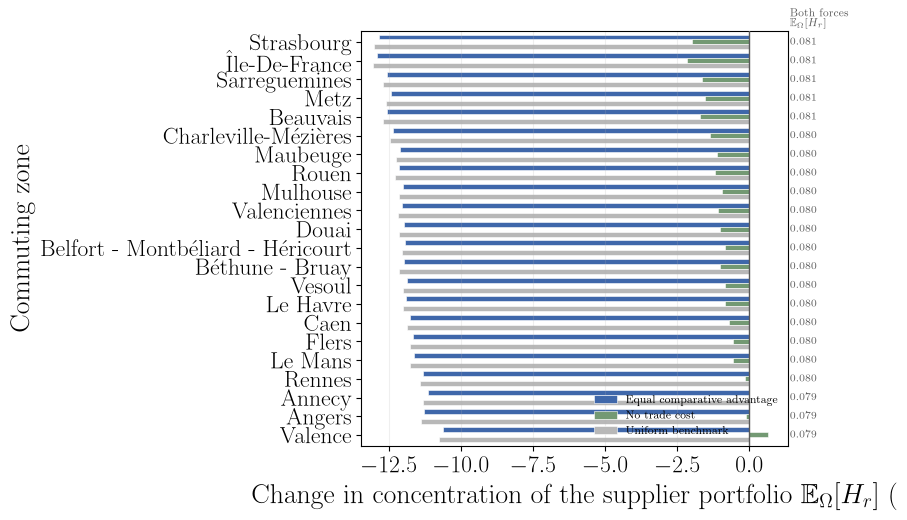

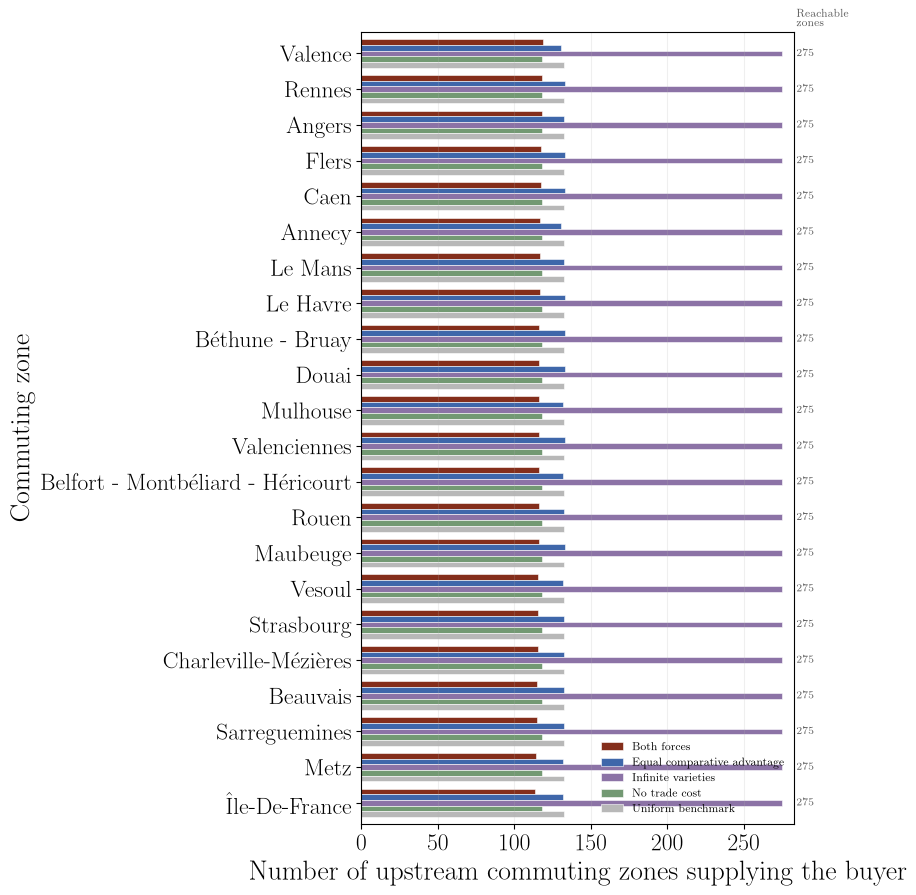


  Table 3 [auto]


,n_eff_rel_uniform,C_structural,n_eff_realised,gran_share,rho_s,rho_floor
regime,,,,,,
Both forces,0.387,0.989,12.480,0.789,0.931,0.045
Equal comparative advantage,0.983,0.988,14.173,0.906,0.935,0.045
No trade cost,0.407,1.000,12.598,0.797,1.000,0.045
Uniform benchmark,1.000,1.000,14.195,0.907,1.000,0.045



[aero, mu = 2] — where the response lands
  concentration and commonality, sector by sector (spend-weighted over buyers)
                                   sector_name  n_cells  spend  h_bar  h_common      m      C    n_eff  n_eff_common  n_hat_s  n_eff_ratio
regime                      sector                                                                                                        
Both forces                 0             C22B      177  0.153  0.013     0.011  0.002  0.867   75.570        87.180     10.0        0.427
                            1             C25D      216  0.289  0.010     0.009  0.001  0.924   98.426       106.553     14.0        0.456
                            2             C26E       96  1.035  0.059     0.053  0.006  0.898   16.904        18.831      9.0        0.176
                            3             C27B      157  0.258  0.011     0.010  0.001  0.921   92.811       100.754     16.0        0.591
                            4             C2

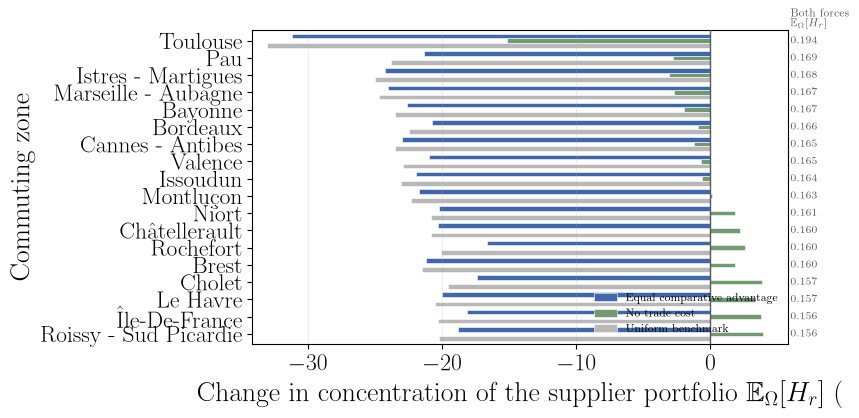

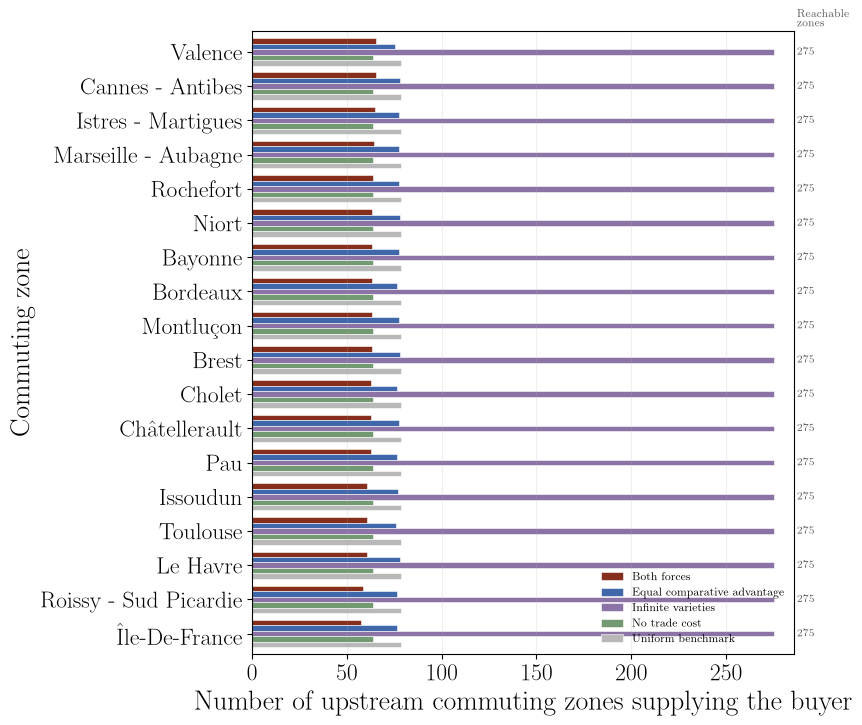


  Table 3 [aero]


,n_eff_rel_uniform,C_structural,n_eff_realised,gran_share,rho_s,rho_floor
regime,,,,,,
Both forces,0.291,0.952,6.092,0.644,0.832,0.056
Equal comparative advantage,0.877,0.884,7.759,0.849,0.812,0.056
No trade cost,0.297,1.000,6.125,0.648,1.000,0.056
Uniform benchmark,1.000,1.000,7.892,0.866,1.000,0.056


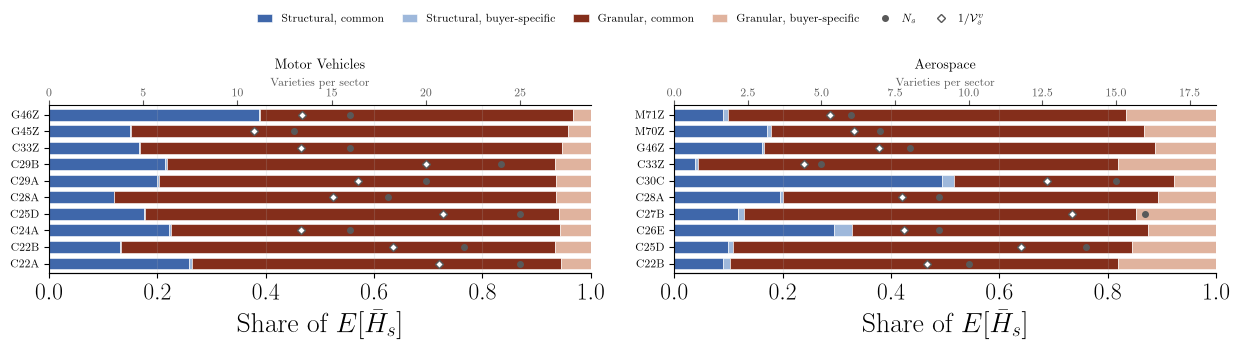

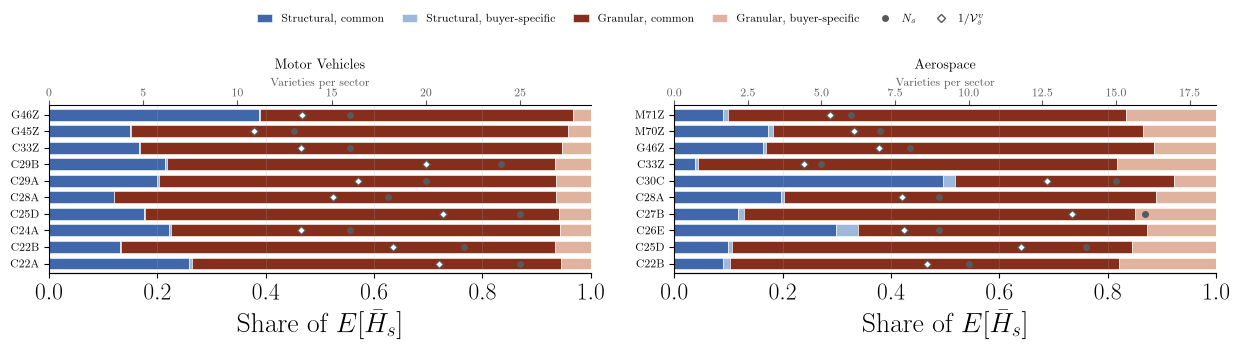


  [Motor Vehicles] model buyer weights against equal buyers (sector weights identical in both)
    effective n_buyers 1/buyer_hhi: 22.00 -> 22.00
       struct_common: +0.0167 -> +0.0167
     struct_specific: +0.0002 -> +0.0002
         gran_common: +0.0588 -> +0.0588
       gran_specific: +0.0044 -> +0.0044
               rho_s: +0.9287 -> +0.9286
           rho_floor: +0.0455 -> +0.0455
          C_realised: +0.9406 -> +0.9405

  [Aerospace] model buyer weights against equal buyers (sector weights identical in both)
    effective n_buyers 1/buyer_hhi: 17.95 -> 18.00
       struct_common: +0.0556 -> +0.0560
     struct_specific: +0.0028 -> +0.0030
         gran_common: +0.0879 -> +0.0876
       gran_specific: +0.0178 -> +0.0181
               rho_s: +0.8357 -> +0.8333
           rho_floor: +0.0557 -> +0.0556
          C_realised: +0.8789 -> +0.8767


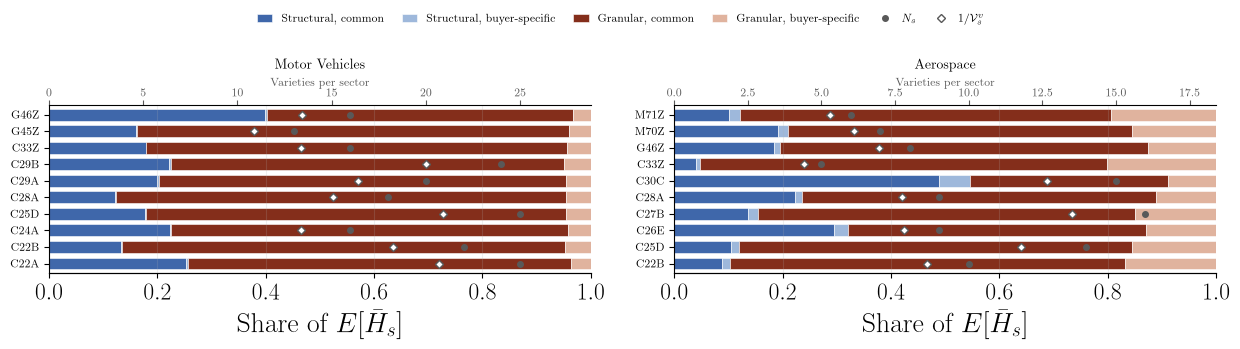


  [Motor Vehicles] model buyer weights against size-weighted buyers (sector weights identical in both)
    effective n_buyers 1/buyer_hhi: 22.00 -> 3.33
       struct_common: +0.0167 -> +0.0173
     struct_specific: +0.0002 -> +0.0002
         gran_common: +0.0588 -> +0.0597
       gran_specific: +0.0044 -> +0.0034
               rho_s: +0.9287 -> +0.9447
           rho_floor: +0.0455 -> +0.2998
          C_realised: +0.9406 -> +0.9542

  [Aerospace] model buyer weights against size-weighted buyers (sector weights identical in both)
    effective n_buyers 1/buyer_hhi: 17.95 -> 3.28
       struct_common: +0.0556 -> +0.0583
     struct_specific: +0.0028 -> +0.0066
         gran_common: +0.0879 -> +0.0846
       gran_specific: +0.0178 -> +0.0205
               rho_s: +0.8357 -> +0.8063
           rho_floor: +0.0557 -> +0.3057
          C_realised: +0.8789 -> +0.8435


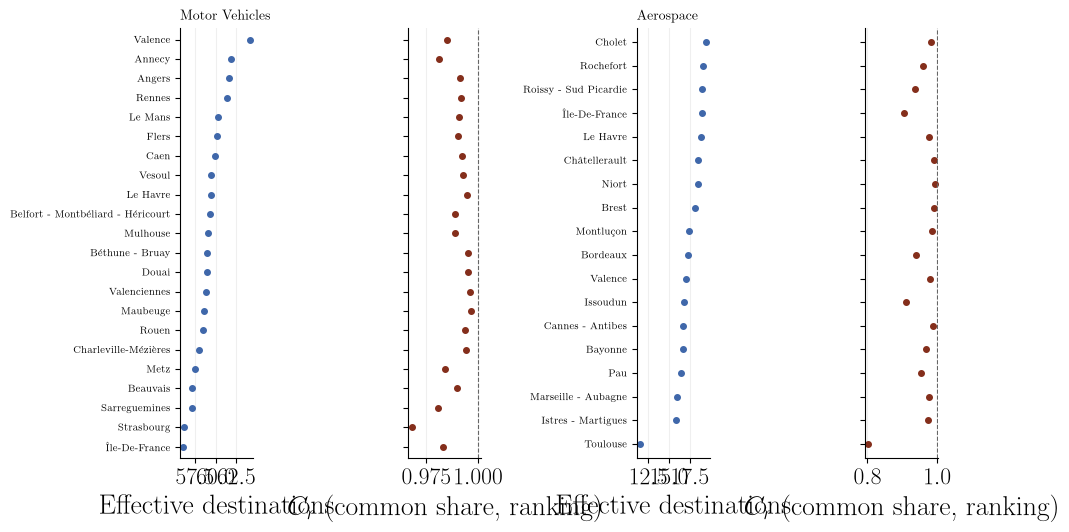

In [31]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
conc_sector, conc_gran, conc_buyers, conc_var, conc_bgran, conc_reach = {}, {}, {}, {}, {}, {}
conc_gran_eq = {}          # the same four cells with every buyer weighted equally
conc_gran_sz = {}          # and weighted by buyer SIZE (the empirical pi_r)
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    # the ESTIMATED economy, simulated from theta+ -- `reporting_data` caches,
    # so the sections share one solve rather than re-solving each
    data = reporting_data(industry, mu=MU, **RUN_KWARGS)["Both forces"]
    globals().update(data)

    print(f"\n[{industry}, mu = {MU}] — where the response lands")
    rep = concentration_report(data, industry=industry)
    conc_sector[cfg["display_name"]] = rep["sector"]
    conc_buyers[cfg["display_name"]] = rep["buyers"]
    if rep["buyer_granular"] is not None:
        conc_bgran[cfg["display_name"]] = rep["buyer_granular"]
        # the per-buyer counterfactual figure, one file per industry, in
        # `plot_counterfactual_distance`'s form: PERCENTAGE deviations from the
        # estimated economy, so the origin is the baseline and a bar's length IS the
        # effect; the level of H is printed at the right margin, so every percentage
        # converts back. H itself and not its reciprocal, because the decomposition is
        # written in H. `Infinite varieties` is DROPPED (the function's default): it
        # sits an order of magnitude below the rest and would crush the two force
        # counterfactuals into the zero rule — granularity is the largest of the three
        # effects and belongs in the text as one number, not on this axis.
        plot_buyer_granular_concentration(
            rep["buyer_granular"], quantity="h", units="pct", kind="bar",
            save_to=f"{out_folder}/buyer_concentration_region_{industry}_mu{MU}.pdf")
        plt.show()
    if rep["reach"] is not None:
        conc_reach[cfg["display_name"]] = rep["reach"]
        # the region count, which carries no variety weighting at all
        plot_buyer_region_reach(
            rep["reach"],
            save_to=f"{out_folder}/buyer_reach_region_{industry}_mu{MU}.pdf")
        plt.show()
    if rep["granular"] is not None:
        conc_gran[cfg["display_name"]] = rep["granular"]
        if rep.get("granular_equal") is not None:
            conc_gran_eq[cfg["display_name"]] = rep["granular_equal"]
        if rep.get("granular_size") is not None:
            conc_gran_sz[cfg["display_name"]] = rep["granular_size"]
        conc_var[cfg["display_name"]] = rep["variety"]
    if rep["table"] is not None:
        print(f"\n  Table 3 [{industry}]")
        display(rep["table"].round(3))

# the granularity figure: the four cells per sector, N_s and 1/V on a twin axis
if conc_gran:
    plot_concentration_decomposition(
        conc_gran, variety=conc_var,
        save_to=f"{out_folder}/concentration_decomposition_mu{MU}.pdf")
    plt.show()

# The same figure under two other buyer weightings. Read the three cell by cell, not
# one at a time. `buyer_hhi` below is what says whether a reweighting reached `pi` at
# all: under EQUAL weights it must be 1/n_buyers exactly.
for _lbl, _tabs, _suffix in (("equal buyers", conc_gran_eq, "equal"),
                             ("size-weighted buyers", conc_gran_sz, "size")):
    if not _tabs:
        continue
    plot_concentration_decomposition(
        _tabs, variety=conc_var,
        save_to=f"{out_folder}/concentration_decomposition_{_suffix}_mu{MU}.pdf")
    plt.show()
    for _k, _t in _tabs.items():
        _b = conc_gran.get(_k)
        if _b is None:
            continue
        _w = _b["spend"] / _b["spend"].sum()      # the SECTOR weights, unchanged
        _n = float(_w @ (1.0 / _b["buyer_hhi"]))
        print(f"\n  [{_k}] model buyer weights against {_lbl} "
              "(sector weights identical in both)")
        print(f"    effective n_buyers 1/buyer_hhi: {_n:.2f} -> "
              f"{float(_w @ (1.0 / _t['buyer_hhi'])):.2f}")
        for _c in ("struct_common", "struct_specific", "gran_common",
                   "gran_specific", "rho_s", "rho_floor", "C_realised"):
            print(f"    {_c:>16}: {float(_w @ _b[_c]):+.4f} -> "
                  f"{float(_w @ _t[_c]):+.4f}")

# the appendix figure: every buyer's effective number and its C_r, one row order
plot_buyer_concentration(
    conc_buyers, save_to=f"{out_folder}/buyer_concentration_mu{MU}.pdf")
plt.show()


## Test 6 — how much of the shock does the region keep, and how reliably?

How far the euro travels is not the same question as how much of it the shocked region
retains, and it is the second that the reduced-form part of the paper measures:

$$L_r(d) = \frac{\sum_{r' : d_{r'r} \le d} X_{r'r}}{\sum_{r'} X_{r'r}}.$$

The denominator is UPSTREAM SALES ONLY — the euro of downstream demand is not in it — so it is
a share of what propagates. The radius is a free parameter throughout; the headline is 200 km,
the radius of the reduced-form evidence, and `local_share_profile` sweeps it so that number is
visibly one point on a CDF rather than assumed robust.

The test has two halves and they are the same statistic read twice: the **level**, region by
region and with each force switched off, and the **dispersion** around it, which exists because
with $N_s$ finite the realised network is a random object. They were written as two tests and
are merged here, since a level without its band and a band without its level are each half an
answer.

### The level, and the sign reversal

**This is the section's sharpest result.** In motor vehicles the two forces reinforce: removing
either lowers the local share. In aerospace they work against each other — equalising $\hat T$
*raises* it. Comparative advantage there is not a localising force at all: it takes the response
off the region where the shock starts and sends it to the hubs. That is precisely the
reallocation the average distance of test 4 nearly cancels, which is why $d_r$ and $L_r$ are
both needed rather than one being a check on the other.

The map is drawn because $L_r(d)$ is a number attached to a PLACE, and a bar chart sorted by
value destroys exactly the geography the result claims. Its colour scale is PINNED and shared
across the pair: the content is that aerospace reaches 0.56 where motor vehicles never passes
0.44, and a per-panel scale would rescale that away and paint the two maps alike.

### The dispersion, and why it separates cleanly

Because $L_r(d)$ is **linear** in the realised network, where the Herfindahl of test 5 bis is
quadratic, its two halves separate instead of having to be decomposed. Writing
$\omega_{lrs}(\Omega)$ for the share of buyer $r$'s sector-$s$ purchases landing on upstream
cell $l$, and taking any indicator $h_l$ over cells,

$$\mathbb{E}_\Omega\Big[\sum_l h_l\,\omega_{lrs}\Big] = p_{rs} := \sum_l h_l\,\gamma_{lrs},
\qquad
\operatorname{Var}_\Omega\Big(\sum_l h_l\,\omega_{lrs}\Big) = V_{rs}\;p_{rs}\,(1-p_{rs}).$$

Both follow from the one kernel the section already uses,
$\mathbb{E}[\omega_l\omega_m] = V\gamma_l\mathbf{1}\{l=m\} + (1-V)\gamma_l\gamma_m$ — the same
object that gives $\mathbb{E}[H] = V + (1-V)H(\gamma)$ — since it makes
$\operatorname{Var}(\sum_l h_l\omega_l) = V\operatorname{Var}_\gamma(h)$, and the variance of an
indicator under $\gamma$ is $p(1-p)$. With $h_l = \mathbf{1}\{l = r\}$ this is the own-zone
share; with $h_l = \mathbf{1}\{d_{lr} \le d\}$ it is the $L_r(d)$ of the half above. The radius
is therefore a reporting choice, not a second derivation — and the one reported is **200 km**,
because the own-zone share is an order of magnitude lower, which flattens the band and leaves
the figure with nothing to read.

**So there is nothing structural-against-granular to split in the level.** The point *is* the
continuum benchmark, exactly, and the whole of granularity sits in the spread. That is why this
is a level opposed to a dispersion and not the stacked decomposition of test 5 bis. It also
buys a free specification check: $\mathbb{E}[\omega] = \gamma$ is exact, so the gap between the
realised mean and the closed-form level is pure simulation error, and a large $z$ means the
variety panel and the structural network are not the same economy.

Aggregated over a buyer's sectors with its input mix $\theta_{rs} = X_{rs}/X_r$, and using that
sectors draw their varieties independently,

$$\bar\omega_{r} = \sum_s \theta_{rs}\,\omega_{rs}, \qquad
\mathbb{E}[\bar\omega_r] = \sum_s \theta_{rs}\,p_{rs}, \qquad
\sigma_r^2 = \sum_s \theta_{rs}^{2}\,V_{rs}\,p_{rs}(1-p_{rs}).$$

The weights enter **squared**, so aggregating ten sectors diversifies most of the chance away
before it reaches the figure. That is a property of the statistic and not of the economy, which
is why the per-sector view is kept and the two sectors carrying the most spending are drawn on
their own.

**The band is a quantile range, not $\pm\sigma$, and that is a statement about the law rather
than about taste.** Where $p_r \times N^{\text{eff}}_r$ is of order one the realised local
share is a count of a handful of events: a buyer at 5% with five effective varieties realises
0 or 0.2, never 0.05. The standard deviation exists but describes that distribution badly — it
is discrete and skewed, and a symmetric bar draws a shape the data do not have. The figure
therefore carries the empirical **10–90 percentiles of the draws**, which impose nothing and
let the asymmetry show.

**What the band is, and what it is not.** Every replication is drawn at the *same* $\theta^+$,
so the band is **granularity**: at these fundamentals, the range within which eight realised
economies out of ten place the statistic. It carries none of the uncertainty in
$(\hat\alpha, \hat T, \hat N)$ — it is not a confidence interval and is never captioned as
one. Two numbers say whether it reads as written. `coverage` is the share of realisations that
actually fall inside $[q_{10}, q_{90}]$: on a continuous law it is 0.80, but the realised share
lives on a **lattice** $\{0, 1/N^{\text{eff}}, 2/N^{\text{eff}}, \dots\}$, so with few atoms
the interval over-covers — up to 1.0 — while its width jumps by whole lattice steps and can
collapse to zero when one atom carries more than 80% of the mass. `p_n_eff` says how fine that
lattice is, and is read first.

**Two readings, and the second is a question the numbers have to settle.** First, $p(1-p)$ is
maximal at $p = 1/2$ and vanishes at both ends, so the buyers whose local sourcing is
*intermediate* are the ones whose realised local share says least: one observed at 60% local in
a given year can sit at 35% the next with no fundamental having moved. Second, cutting trade
costs lowers the point, and the hope is that it *raises* the bar by pushing $\gamma$ towards the
middle — the compensation the Herfindahl shows, chance filling the dispersion geography vacates.
That requires $p$ to be pushed **towards** one half; below it the bar rises and falls *with* the
point, so which statement holds is empirical. `local_share_report` counts the buyers moving each
way and reports the share sitting past $1/2$, so the conjecture is decided rather than
restated.

**Two notes the band must carry.** $\theta_{rs}$ is held at its mean, so the reported
dispersion is the **network's alone**; in the realised economy the sector mix moves with the
draw too, and the observable variability is larger. And these bands are **per buyer**: the industry's aggregate local share needs $\operatorname{Cov}_\Omega$ *between*
buyers — cells (iii) and (iv) of test 5 bis — so its band is not the average of these.

**The layout, and where the draws come from.** The default is **small multiples** — one panel
per regime, one mark per buyer row, a single shared window and the same rows throughout — rather
than the three regimes overlaid. With bands whose arms are of the order of the between-regime
movement, an overlay puts three marks and three bands in every row and they interleave, so the
reader has to separate colour from vertical offset before reading a level; laid out side by side
each regime is read as a shape, and each counterfactual panel carries the estimated economy's
point as a faint open mark so the displacement needs no cross-panel saccade. `layout="overlay"`
restores the single panel. The axis names the quantity and nothing else: what the point and the
bar are, and which sector is drawn, are facts about the exhibit and belong in the caption.

Finally, the draws. **Every regime, the estimated economy included, is redrawn in Python** by
`simulate_granular_regime` from `theta+` — successive replications are successive draws from one
`default_rng` stream, so realisations are independent of one another. (Until the modules were
split, `Both forces` was read off `suppliers.parquet` instead and the two routes had to be read
against each other; now there is one route, and `check_against_julia` is what ties it to Julia.)
Within a replication one Fréchet draw per (variety, cell) is **shared across buyers** — it is
the same physical variety — which is what makes chance common rather than idiosyncratic. So the
realisations are independent and the buyers within one are not, and it is the second that the
per-buyer caveat above is about.



=== [auto, mu = 2] ==============================================
  within 100 km: mean 0.071, median 0.055, min 0.020, max 0.170
  within 200 km: mean 0.234, median 0.211, min 0.137, max 0.421


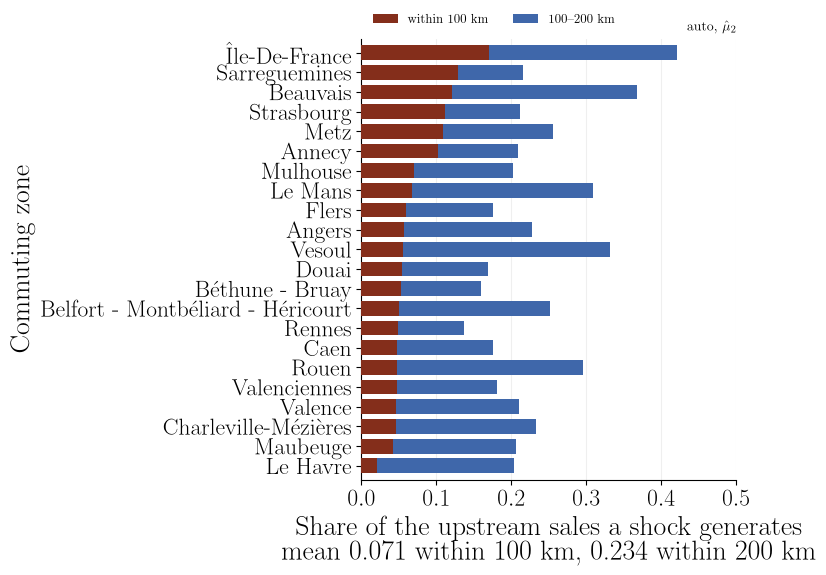

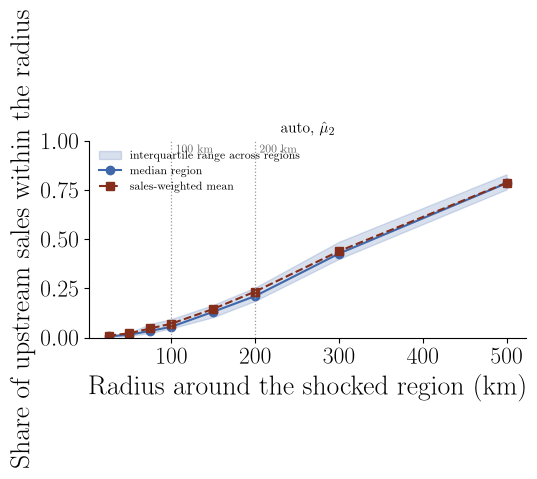

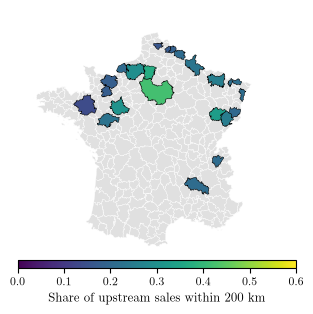

  [counterfactual] D_r RANGES 0.0496 across regimes: these frames come from re-solved economies, so the intermediate expenditure share has responded
  [counterfactual] and matches the realised D_r to 0.00e+00
  [counterfactual] share_within_100km: realised 0.071 vs closed-form both-forces 0.071 — the gap is granularity, not a different economy


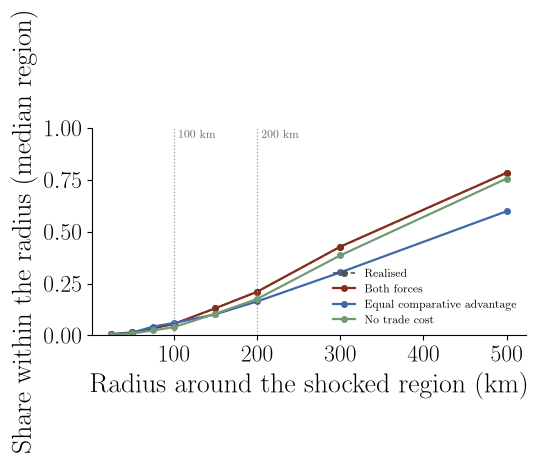

  the local share of the portfolio — within 200 km of the buyer
                             local (median)  local (min)  local (max)  q10 (median)  q90 (median)  width (median)  coverage (median)   draws
regime                                                                                                                                      
Both forces                          0.2102       0.1387       0.4219        0.1652        0.2598          0.0948                0.8  1000.0
Equal comparative advantage          0.1637       0.1076       0.3391        0.1216        0.2072          0.0857                0.8  1000.0
No trade cost                        0.1756       0.1120       0.3659        0.1316        0.2212          0.0907                0.8  1000.0
    p x N_eff (the effective varieties landing locally): median 3.3, min 2.2, max 6.6 at N_eff median 15.5  <-- of order one: the realised share is a few discrete events, so the band is skewed for a counting reason
    E[omega] = g

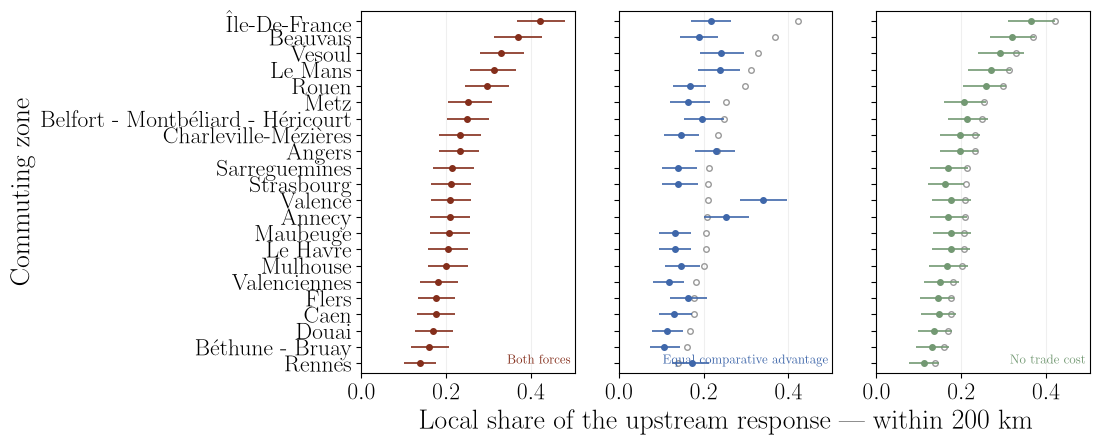

,local,q10,q90,width,coverage,p_n_eff,n_draws,region
ze2010_downstream,,,,,,,,
12,0.422,0.368,0.480,0.112,0.8,6.568,1000.0,Île-De-France
13,0.233,0.184,0.283,0.099,0.8,3.617,1000.0,Charleville-Mézières
26,0.369,0.313,0.426,0.113,0.8,5.738,1000.0,Beauvais
36,0.206,0.158,0.251,0.093,0.8,3.197,1000.0,Le Havre
37,0.298,0.244,0.349,0.105,0.8,4.626,1000.0,Rouen
58,0.177,0.131,0.221,0.090,0.8,2.745,1000.0,Caen
68,0.177,0.133,0.220,0.087,0.8,2.751,1000.0,Flers
88,0.168,0.127,0.215,0.088,0.8,2.612,1000.0,Douai
89,0.181,0.138,0.229,0.091,0.8,2.813,1000.0,Valenciennes



=== [aero, mu = 2] ==============================================
  within 100 km: mean 0.093, median 0.056, min 0.007, max 0.432
  within 200 km: mean 0.219, median 0.195, min 0.030, max 0.635


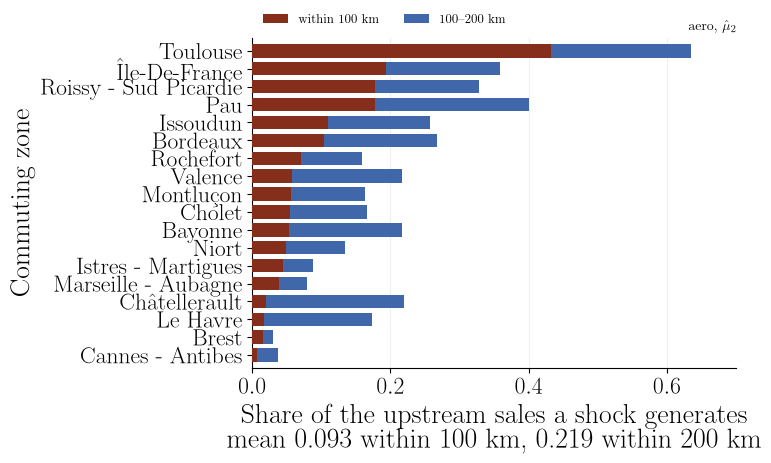

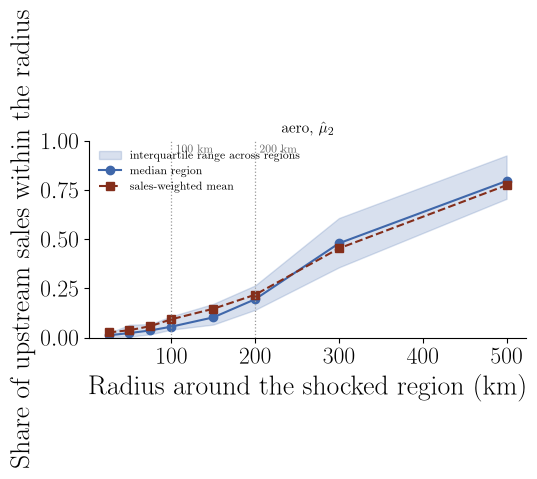

  [map] 1 zone(s) above the pinned vmax = 0.6 and so clipped: Toulouse — widen LOCAL_SHARE_MAP_VLIM.


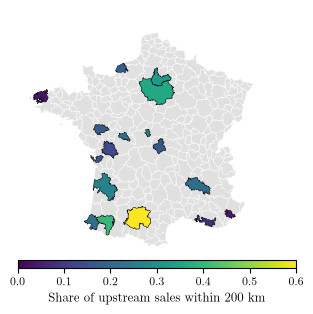

  [counterfactual] D_r RANGES 0.1163 across regimes: these frames come from re-solved economies, so the intermediate expenditure share has responded
  [counterfactual] and matches the realised D_r to 0.00e+00
  [counterfactual] share_within_100km: realised 0.093 vs closed-form both-forces 0.093 — the gap is granularity, not a different economy


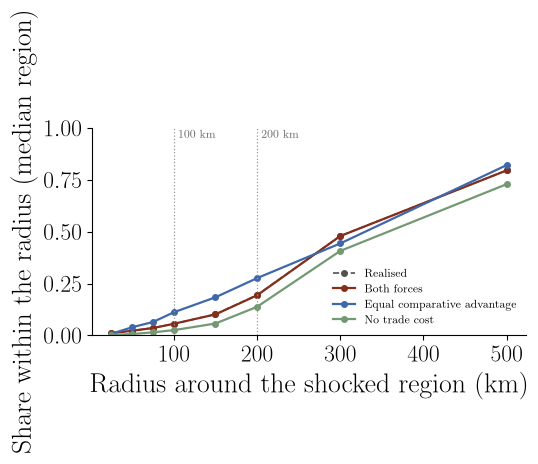

  the local share of the portfolio — within 200 km of the buyer
                             local (median)  local (min)  local (max)  q10 (median)  q90 (median)  width (median)  coverage (median)   draws
regime                                                                                                                                      
Both forces                          0.1933       0.0300       0.6343        0.1081        0.2889          0.1808                0.8  1000.0
Equal comparative advantage          0.2762       0.0248       0.4306        0.1694        0.3908          0.2206                0.8  1000.0
No trade cost                        0.1380       0.0140       0.5029        0.0618        0.2180          0.1534                0.8  1000.0
    p x N_eff (the effective varieties landing locally): median 1.7, min 0.3, max 5.5 at N_eff median 9.0  <-- of order one: the realised share is a few discrete events, so the band is skewed for a counting reason
    E[omega] = ga

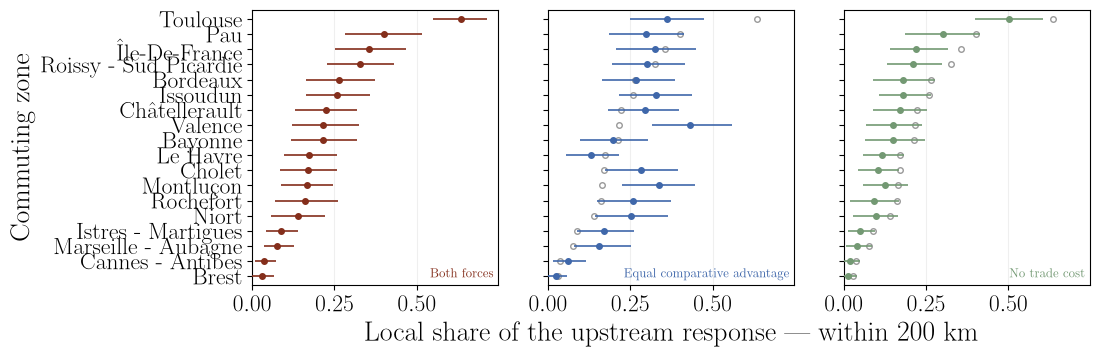

,local,q10,q90,width,coverage,p_n_eff,n_draws,region
ze2010_downstream,,,,,,,,
7,0.327,0.227,0.430,0.202,0.8,3.016,1000.0,Roissy - Sud Picardie
11,0.634,0.549,0.712,0.164,0.8,5.512,1000.0,Toulouse
12,0.355,0.251,0.468,0.217,0.8,3.271,1000.0,Île-De-France
36,0.172,0.098,0.257,0.159,0.8,1.582,1000.0,Le Havre
45,0.259,0.163,0.357,0.194,0.8,2.347,1000.0,Issoudun
137,0.170,0.084,0.257,0.173,0.8,1.538,1000.0,Cholet
156,0.030,0.000,0.065,0.065,0.9,0.274,1000.0,Brest
170,0.223,0.129,0.318,0.188,0.8,2.013,1000.0,Châtellerault
176,0.161,0.069,0.260,0.191,0.8,1.434,1000.0,Rochefort


In [32]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
# The local share as a LEVEL (with each force switched off) and then as a level plus a
# DISPERSION. One statistic, read twice; these were tests 6 and 9 and are merged.
ls_tabs = {}
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    name = cfg.get("display_name", industry)
    # the ESTIMATED economy, simulated from theta+ -- `reporting_data` caches,
    # so the sections share one solve rather than re-solving each
    data = reporting_data(industry, mu=MU, **RUN_KWARGS)["Both forces"]
    globals().update(data)

    print(f"\n=== [{industry}, mu = {MU}] " + "=" * 46)
    diff = build_diffusion_frame(data)
    summ = amplification_summary(data, radii=AMPLIFICATION_RADII, diffusion=diff)
    prof = local_share_profile(data, diffusion=diff)

    # ---------------------------------------------------------------- the LEVEL
    for d in AMPLIFICATION_RADII:
        c = f"share_within_{int(d)}km"
        print(f"  within {d:g} km: mean {summ[c].mean():.3f}, "
              f"median {summ[c].median():.3f}, min {summ[c].min():.3f}, max {summ[c].max():.3f}")

    plot_local_share(data, radii=AMPLIFICATION_RADII, summary=summ,
                     save_to=f"{out_folder}/local_share_{industry}_mu{MU}.pdf")
    plt.show()
    plot_local_share_profile(data, profile=prof, mark=AMPLIFICATION_RADII,
                             save_to=f"{out_folder}/local_share_profile_{industry}_mu{MU}.pdf")
    plt.show()

    # the map: L_r(d) is a number attached to a place. Guarded on the geometry.
    try:
        plot_local_share_map(data, radius_km=AMPLIFICATION_RADII[-1], summary=summ,
                             vlim=LOCAL_SHARE_MAP_VLIM_WIDE,
                             save_to=f"{out_folder}/local_share_map{int(AMPLIFICATION_RADII[-1])}km_{industry}_mu{MU}.pdf")
        plt.show()
    except (FileNotFoundError, KeyError, ValueError) as e:
        print(f"  local-share map skipped: {type(e).__name__}: {e}")

    # the sign reversal, region by region and as the whole profile. The frames come from
    # the RE-SOLVED economies, so the intermediate expenditure share responds -- see the
    # channel decomposition in test 4.
    frames = simulated_frames(reporting_data(industry, mu=MU, **RUN_KWARGS))
    det = counterfactual_amplification(data, radii=AMPLIFICATION_RADII,
                                       frames=frames, diffusion=diff)
    plot_counterfactual_profile(data, mark=AMPLIFICATION_RADII, diffusion=diff,
                                save_to=f"{out_folder}/counterfactual_profile_{industry}_mu{MU}.pdf")
    plt.show()

    # ----------------------------------------------------------- the DISPERSION
    # 200 km, the section's own radius: the algebra is the same indicator for any radius,
    # and the own-zone share (`radius_km=None`) sits an order of magnitude lower, which
    # flattens the band and leaves the figure mute.
    tag = f"{int(LOCAL_SHARE_RADIUS_KM)}km"
    try:
        tab = local_share_dispersion(data, radius_km=LOCAL_SHARE_RADIUS_KM)
    except (FileNotFoundError, KeyError, ValueError) as e:
        print(f"  local-share dispersion skipped: {type(e).__name__}: {e}")
        continue
    local_share_report(tab)
    ls_tabs[(name, tag)] = tab

    # the band is the 10-90 range of the realised economies -- GRANULARITY at a fixed
    # theta+, not estimation uncertainty, so it is never captioned a confidence interval
    plot_local_share_dispersion(
        tab,
        save_to=f"{out_folder}/local_share_dispersion_{tag}_{industry}_mu{MU}.pdf")
    plt.show()

    # the band, and the two numbers that say whether it reads as written: `coverage`
    # (does [q10, q90] hold 80% of the economies, or is it over-covering a lattice)
    # and `p_n_eff` (how fine that lattice is)
    _c = tab.loc["Both forces"]
    display(_c[["local", "q10", "q90", "width", "coverage", "p_n_eff",
                "n_draws", "region"]].round(3))


## Test 7 — what does the finite variety count cost?

With $N_s$ finite the network is a RANDOM object, so no single realisation is a result. This
test is not a caveat on tests 1–6; it measures something they cannot see.

**What is invariant, and why.** Under Fréchet the identity of a variety's winner is
independent of its realised price, so conditionally on prices the location indicators are
i.i.d. and independent of them: $\mathbb{E}[L_r(d)]$ is EXACTLY invariant to $N_s$ — the same
argument that gives $\hat q \perp N_s$. The point estimates of tests 1, 3 and 6 were therefore
right whatever the variety count.

**What is not.** The SUPPORT: a buyer sources $\sum_s \hat N_s$ varieties, so a shock reaches a
few dozen origins rather than every commuting zone, and the loss is larger in the industry
where comparative advantage concentrates sourcing. The DISPERSION: the spread of $L_r(100)$
across realisations is of the same order as its mean, so the cross-region contrast the map
reports (a contrast of expectations) stands while a statement about one region in one year does
not. And $D_r$ rises: the within-sector index is convex in the draws, so a finite basket is on
average dearer, and with $\lambda < 1$ that raises the intermediate share — the price-index
channel, which is why the gap from the continuum is not sampling noise.


In [33]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    # the ESTIMATED economy, simulated from theta+ -- `reporting_data` caches,
    # so the sections share one solve rather than re-solving each
    data = reporting_data(industry, mu=MU, **RUN_KWARGS)["Both forces"]
    globals().update(data)

    print(f"[{industry}, mu = {MU}]")
    try:
        # The infinite-variety benchmark is SIMULATED here --
        # `n_var` varieties per sector instead of N_hat_s -- where
        # it used to be read from Julia's second parquet. Julia's
        # continuum solve is the Monte-Carlo evaluation of the same
        # limit, so the estimator is unchanged; `n_var` is a
        # numerical knob, and the limit is approached at rate 1/n_var,
        # so read the gap against a doubled n_var before quoting it.
        cont = continuum_data(data, data["xp"], n_var=200, n_rep=8)
        granularity_report(data, radii=AMPLIFICATION_RADII,
                           continuum=cont["suppliers"])
        # the spread one draw carries, region by region
        display(granular_band(data, radii=AMPLIFICATION_RADII).round(3))
    except (FileNotFoundError, KeyError, ValueError) as e:
        print(f"  granularity report skipped: {type(e).__name__}: {e}")


[auto, mu = 2]
  granularity = the finite-variety economy minus its N_s -> infinity limit (1000 realisations):
                        granular_mean  sd_across_draws  continuum  granularity  granularity_rel
quantity                                                                                       
amplification                  1.8323           0.0055     1.8334      -0.0011          -0.0006
mean_upstream_distance       349.5457          16.4812   346.8768       2.6689           0.0077
supplier_cells               116.1061           5.0438   252.9545    -136.8485          -0.5410
share_within_100km             0.0708           0.0224     0.0684       0.0024           0.0351
share_within_200km             0.2341           0.0382     0.2295       0.0047           0.0203
  a shock reaches 116 origins with N_hat_s varieties against 253 in the continuum — the extensive margin is the whole of what granularity is for.


,region,amplification,amplification_sd,mean_upstream_distance,mean_upstream_distance_sd,supplier_cells,supplier_cells_sd,share_within_100km,share_within_100km_sd,share_within_200km,share_within_200km_sd,n_replications
ze2010_downstream,,,,,,,,,,,,
12,Île-De-France,1.830,0.006,262.438,15.715,113.587,5.193,0.170,0.034,0.421,0.045,1000
13,Charleville-Mézières,1.832,0.006,336.493,16.907,115.041,5.096,0.046,0.020,0.233,0.039,1000
26,Beauvais,1.831,0.006,300.009,16.550,114.741,5.143,0.121,0.029,0.368,0.045,1000
36,Le Havre,1.833,0.006,370.147,16.919,116.687,5.083,0.020,0.013,0.204,0.037,1000
37,Rouen,1.832,0.006,330.204,16.570,115.892,5.147,0.047,0.018,0.295,0.042,1000
58,Caen,1.833,0.006,376.007,16.967,117.245,5.104,0.048,0.020,0.176,0.034,1000
68,Flers,1.833,0.006,367.390,16.796,117.517,5.102,0.060,0.023,0.175,0.034,1000
88,Douai,1.833,0.006,370.539,17.804,116.131,5.120,0.054,0.020,0.169,0.034,1000
89,Valenciennes,1.833,0.006,369.509,17.653,115.961,5.072,0.047,0.019,0.181,0.035,1000


[aero, mu = 2]
  granularity = the finite-variety economy minus its N_s -> infinity limit (1000 realisations):
                        granular_mean  sd_across_draws  continuum  granularity  granularity_rel
quantity                                                                                       
amplification                  1.8694           0.0094     1.8644       0.0050           0.0027
mean_upstream_distance       348.4570          26.9559   352.6754      -4.2183          -0.0120
supplier_cells                62.2016           3.8500   181.8889    -119.6873          -0.6580
share_within_100km             0.0935           0.0445     0.0887       0.0048           0.0536
share_within_200km             0.2186           0.0658     0.2124       0.0062           0.0294
  a shock reaches 62 origins with N_hat_s varieties against 182 in the continuum — the extensive margin is the whole of what granularity is for.


,region,amplification,amplification_sd,mean_upstream_distance,mean_upstream_distance_sd,supplier_cells,supplier_cells_sd,share_within_100km,share_within_100km_sd,share_within_200km,share_within_200km_sd,n_replications
ze2010_downstream,,,,,,,,,,,,
7,Roissy - Sud Picardie,1.870,0.010,379.422,39.464,58.392,3.932,0.178,0.068,0.328,0.082,1000
11,Toulouse,1.858,0.009,221.533,30.405,60.149,3.771,0.432,0.088,0.635,0.073,1000
12,Île-De-France,1.869,0.010,351.997,40.194,56.989,3.895,0.193,0.072,0.359,0.086,1000
36,Le Havre,1.874,0.009,458.929,37.161,60.095,3.970,0.017,0.013,0.173,0.062,1000
45,Issoudun,1.866,0.010,269.155,20.878,60.337,3.795,0.109,0.059,0.258,0.075,1000
137,Cholet,1.870,0.009,335.232,24.452,62.366,3.960,0.055,0.042,0.167,0.068,1000
156,Brest,1.878,0.009,591.354,29.833,62.799,3.907,0.016,0.021,0.030,0.027,1000
170,Châtellerault,1.868,0.009,288.834,17.933,62.133,3.955,0.021,0.023,0.220,0.073,1000
176,Rochefort,1.868,0.009,308.340,22.714,63.681,3.886,0.070,0.052,0.159,0.073,1000


## Test 8 — do suppliers share a clientele, or are they segmented?

**COMMENTED OUT for speed.** The run cell below is inert; uncomment it to run the test.

Every test above reads a BUYER's portfolio of suppliers. This one turns the same matrix on
its side and reads a SUPPLIER's portfolio of customers — the object a supplier-side shock
acts on, and the one that says whether two upstream cells are exposed to the same demand.

**Similarity.** Supplier cell $j$ of sector $s$ sells $x_{jr} = \pi_r\,\gamma_{jrs}$ to each
downstream buyer $r$. Two suppliers are compared by the angle between their portfolios,

$$C_{jk} \;=\; \frac{\langle x_j, x_k\rangle}{\lVert x_j\rVert\,\lVert x_k\rVert},$$

collected into the sector matrix $C_s$. The cosine is **scale-invariant**, so sales shares
and raw sales give the same $C_{jk}$: normalising portfolios is not a modelling choice and
the per-sector spending level cancels. What does not cancel is the weighting of the BUYER
axis — $\pi_r$ rescales the coordinates and therefore the angle — so the buyer weights are
a decision and are reported as one.

**Groups.** The decomposition below needs a partition, and $C_s$ is what there is to build
one from: a link between $j$ and $k$ when $C_{jk} > \tau$, then the connected components of
that graph. Two weaknesses are worth stating rather than defending. The threshold is
arbitrary, so it is swept over $\tau \in \{0.6, 0.7, 0.8\}$ rather than fixed. And connected
components **chain** — $A\!\sim\!B$ and $B\!\sim\!C$ merge $A$ with $C$ however small
$C_{AC}$ is — which a modularity algorithm (Louvain/Leiden on the weighted graph) would
avoid; here the chaining is visible as a single giant component at low $\tau$, which the
reported group count and largest-group share expose.

**Decomposition.** With groups $g$ of size $N_g$, and all sums over ORDERED pairs $j \neq k$,

$$C^{within}_s=\frac{\sum_g \sum_{j\neq k \in g} C_{jk}}{\sum_g N_g(N_g-1)},
\qquad
C^{between}_s=\frac{\sum_{g\neq h}\sum_{j\in g,\,k\in h} C_{jk}}{\sum_{g\neq h} N_g N_h},
\qquad
\Delta C_s = C^{within}_s - C^{between}_s .$$

A singleton contributes nothing to the within sum — its own ordered-pair count is zero —
and its whole row to the between one. **$\Delta C_s > 0$ is mechanically true**: the groups
are cut out of $C$ itself, so this is a statistic of separation and not a test. It acquires
content only against a null, and two are computed. The first is the one the objection
suggests: hold each cell's NUMBER of links fixed, rearrange WHICH links it has
(degree-preserving double-edge swaps), and score the resulting partition on the SAME $C$.
**That null turns out to be mostly uninformative, and the code reports it rather than
hiding it**: a rewired graph of any density is almost always connected, which leaves one
group, no between pairs and no gap to score — `null_degenerate` is the share of draws it
collapses on, and near one it says nothing. The second never degenerates: keep the
observed group SIZES and reassign which cells fill them at random. It asks whether THIS
partition of $C$ separates more than an arbitrary partition of the same shape, which a
sector with one common clientele — every $C_{jk}$ alike, so every partition equivalent —
fails and a segmented one passes. `delta_excess` is the gap against that second null, and
it is the column to read.

**Reading.** $\Delta C_s \simeq 0$ in excess of the null means one common clientele: the
suppliers of a sector face the same buyers in the same proportions, so a demand shock
anywhere upstream is a shock to all of them together. A large excess means segmentation —
blocks of suppliers with their own customers, insulated from each other's demand. The two
are not distinguished by the AVERAGE similarity: a high $\bar C_s$ is compatible with
$C^{within} \gg C^{between}$, which is exactly why the decomposition is needed and the mean
is not reported on its own.


In [34]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
# COMMENTED OUT for speed -- uncomment the block below to run test 8.
# cp = {}
# for cfg in INDUSTRIES:
#     industry = cfg["industry"]
#     # the ESTIMATED economy, simulated from theta+ -- `reporting_data` caches,
#     # so the sections share one solve rather than re-solving each
#     data = reporting_data(industry, mu=MU, **RUN_KWARGS)["Both forces"]
#     globals().update(data)
#     name = cfg.get("display_name", industry)
#
#     print(f"\n=== [{industry}, mu = {MU}] " + "=" * 46)
#     try:
#         cp[name] = customer_portfolio_report(data)
#     except (FileNotFoundError, KeyError, ValueError) as e:
#         print(f"  customer-portfolio similarity skipped: {type(e).__name__}: {e}")
#
# _of = globals().get("out_folder")
# if cp:
#     plot_portfolio_decomposition(
#         cp, save_to=f"{_of}/customer_portfolio_mu{MU}.pdf" if _of else None)
#     plt.show()


# Comparative advantage against distance, within a sector

Inside a sector, competition for a given downstream buyer is between **cells**, and a
cell is a (sector, *region*) pair — not an attraction area. Comparative advantage is what
is constant within an area: every region of area $a$ shares $T_{as}$, but each has its own
distance to each buyer. With Fréchet productivity and wages normalised to one, the
Ricardian competition has a closed form over cells,

$$\rho_{l r s} = \frac{\psi_{l r s}}{\sum_{l'} \psi_{l' r s}}, \qquad
\psi_{l r s} = T_{a(l)s}\, d_{lr}^{-\theta\alpha},$$

so on a log scale the two forces are **additive and directly commensurable**:

$$\log \psi_{l r s} = \log T_{a(l)s} \;-\; \theta\alpha \log d_{lr}.$$

**The comparison is between two regions, not between two areas.** Region $r''$ beats
region $r'$ at buyer $r$ iff

$$\theta\alpha\big(\log d_{r'r} - \log d_{r''r}\big) \;<\; \log T_{a(r'')} - \log T_{a(r')},$$

with the distances measured *from each competing region* to the buyer and the comparative
advantages taken at the area each belongs to. Two things follow that an area-level reading
would miss:

1. when $a(r') = a(r'')$ the right-hand side is exactly zero, so **within an area
   competition is pure distance**. This is the variation that identifies $\alpha$, and it
   is invisible to any statement written in terms of area-level distances;
2. an area's edge does not protect *all* of its regions. It buys a distance handicap that
   each of its regions has to pay for out of its own location.

The section is written cell-by-cell throughout, so the only line that changes on the day
regions are allowed their own $T_{ls}$ deviating from their area's is the one that reads
$T_{a(l)s}$ off the area — nothing downstream assumes comparative advantage is constant
within an area.

**How the section proceeds.** Six tests, each in its own pair of cells (definitions, then
a run cell), building on one another:

| | question | answer |
|---|---|---|
| 1 | How unequal is comparative advantage inside a sector? | the spread of $\hat T$ across areas |
| 2 | What is that inequality worth in distance? | $\Delta \log \hat T / (\theta\hat\alpha)$, against the distances the geography offers |
| 3 | Does the favoured area actually win? | the exact comparison, buyer by buyer, region by region |
| 4 | Which of the two forces disperses the competition more? | the variance decomposition of $\log \psi$ |
| 5 | Is its covariance term telling us about the economy or about the estimator? | the Sinkhorn split of $\operatorname{Cov}(\log \hat T, \log d)$ |
| 6 | How much distance is comparative advantage actually buying? | $\operatorname{Cov}_{\rho}(\log \hat T, \log d)$, and the sourcing distance it moves |

Test 1 is descriptive, 2 turns it into a distance, 3 replaces the average with the exact
statement, and 4–5 ask which force does the work and whether the answer is contaminated by
how $\hat T$ was obtained. Test 6 turns that covariance into the quantity Section 5.1
reports: the distance the average euro travels when comparative advantage is switched
off. A seventh cell collects everything into one table, with a glossary.

What the two forces do to the ALLOCATION is asked where it can be read as an economic
outcome rather than as a concentration index — in the amplification section below, which
propagates an actual shock with each force switched off.

Everything is computed from the estimated $\hat T$ and $\hat\alpha$ in `best_params`, the
distance matrix and $\theta$ — exact rather than Monte-Carlo, and available at either
`mu`. The geometry itself (`unpack_estimated_T`, `sourcing_geometry`) is defined with the
loader rather than here, because the amplification section needs the same win
probabilities to propagate a shock with one force switched off, and a helper with two
consumers cannot live inside either of them. It assumes the $N_{\tau} = 1$ power law $\tau = d^{\alpha}$; under a binned trade
cost there is no single distance elasticity to trade off against $T$, and the functions
refuse to run rather than report the first bin's coefficient. Regional wages are
normalised to one in this calibration, which is why they do not appear in $\psi$.


## Test 1 — how unequal is comparative advantage inside a sector?

The starting point, and purely descriptive: one dot per active attraction area, on a
**base-10 log** scale centred at the sector's median area, so the question "is there one
area that stands out, or is the sector flat?" is answered before anything is traded against
distance. One unit on the axis is an order of magnitude of $\hat T$. The top area is marked
and named.

Read in distance, which is what Test 2 does formally: the trade-off is scale-free, so an
area ahead by $x$ decades of $\hat T$ is offset by $x/(\theta\alpha)$ decades of distance —
about $4.4x$ at the motor-vehicle estimate $\theta\hat\alpha = 0.228$ and $2.2x$ at the
aerospace $0.458$. A dot one unit to the right of the pack is therefore an area that could
sit two to four orders of magnitude further from a buyer and still win, which is why these
gaps have to be checked against the distances the country actually offers rather than read
on their own.

Read the count of regions per area beside it: an area's edge is only as useful as the
locations that can exploit it, and the areas differ enormously in how many commuting zones
they contain. Note also that $\hat T$ is only identified up to a per-sector scale — the
reference area is normalised to one — so only *differences* within a sector mean anything,
which is why the figure is centred at the median.


In [ ]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    # the ESTIMATED economy, simulated from theta+ -- `reporting_data` caches,
    # so the sections share one solve rather than re-solving each
    data = reporting_data(industry, mu=MU, **RUN_KWARGS)["Both forces"]
    globals().update(data)

    plot_ca_distribution(
        data, save_to=f"{out_folder}/ca_distribution_{industry}_mu{MU}.pdf")
    plt.show()
    display(comparative_advantage_frame(data).head(12))


## Test 2 — what is that inequality worth in distance?

The two forces are commensurable on a log scale, so an edge in comparative advantage can be
quoted in kilometres. A gap of $\Delta$ in $\log T$ is offset by a distance ratio of
$\exp\!\big(\Delta/(\theta\alpha)\big)$: how many times further from a buyer a region of the
favoured area may sit than a competing region of the other area, and still win.

That number is only meaningful against the distances the geography actually offers, so it
is compared with two benchmarks, both computed on **cell-to-buyer** distances:

* `geo_log_spread` — the *typical* spread, p90 − p10 of $\log d$ across the regions
  competing for a given buyer, averaged over buyers with their purchase weights. Clearing
  it means the edge beats the distances a buyer ordinarily faces;
* `geo_log_range` — the *extreme* spread, pooled max − min. It is anchored at the
  own-region cell, so one degenerate observation sets it: clearing it means no location in
  the country offsets the edge and the area supplies every buyer.

Both benchmarks are averages of a distribution, which is what Test 3 then removes.


In [ ]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    # the ESTIMATED economy, simulated from theta+ -- `reporting_data` caches,
    # so the sections share one solve rather than re-solving each
    data = reporting_data(industry, mu=MU, **RUN_KWARGS)["Both forces"]
    globals().update(data)

    plot_ca_distance_equivalence(
        data, save_to=f"{out_folder}/ca_distance_equivalence_{industry}_mu{MU}.pdf")
    plt.show()
    display(ca_distance_equivalence(data))


## Test 3 — does the favoured area actually win?

Test 2 compares an average edge with an average spread. Neither average has to hold for any
particular buyer, so here the comparison is made exactly, **buyer by buyer and region by
region**, which is the form the inequality at the top of the section takes.

For each sector let $A^*$ be the area with the highest $\hat T$. For each downstream buyer
$r$, every competing cell $l$ carries a score $\log \psi_{lr} = \log T_{a(l)} - \theta\alpha
\log d_{lr}$, and $A^*$ takes the buyer iff its best cell outscores the best cell outside
it. Two numbers come out, both in log-distance units:

* **`mean_win_margin`** — $\big[\max_{l \in A^*} \log\psi - \max_{l \notin A^*}
  \log\psi\big]/(\theta\alpha)$: how much further from this buyer the favoured area's best
  region could be and still win. Positive means it wins; `share_buyers_won` is the
  purchase-weighted share of buyers it takes;
* **`mean_within_penalty`** — $\log d$ of the worst region of $A^*$ minus that of its best,
  for the same buyer. Inside an area $T$ cancels exactly, so this comparison is **pure
  geography**: it is the handicap the area's own spread imposes on its worst region, and it
  is the variation that identifies $\alpha$.

Putting the two side by side answers a question the area-level statement cannot even pose:
does it matter more *which area* a supplier belongs to, or *which region of it* it sits in?
When the second bar is longer than the first, the answer is the region — and that is
exactly the case in which letting regions deviate from their area's $T$ would change the
picture most.


In [ ]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    # the ESTIMATED economy, simulated from theta+ -- `reporting_data` caches,
    # so the sections share one solve rather than re-solving each
    data = reporting_data(industry, mu=MU, **RUN_KWARGS)["Both forces"]
    globals().update(data)

    plot_ca_win_margin(
        data, save_to=f"{out_folder}/ca_win_margin_{industry}_mu{MU}.pdf")
    plt.show()
    display(ca_win_margin(data))


## Test 4 — which force disperses the competition more?

Tests 2 and 3 ask who wins. This one asks which force is doing the work, and it is an
identity rather than a regression. Because $\log\psi$ is a sum, its dispersion across the
cells competing for a given buyer splits *exactly*:

$$\operatorname{Var}(\log\psi) = \operatorname{Var}(\log T) + (\theta\alpha)^2\operatorname{Var}(\log d) - 2\theta\alpha\operatorname{Cov}(\log T, \log d).$$

Variances are taken **across cells at a fixed buyer** — the competition the model actually
runs — and then averaged over buyers with their purchase weights.
$\operatorname{sd}(\log T)$ against $\theta\alpha\operatorname{sd}(\log d)$ is the
like-for-like size of the two pulls, and `ratio_CA_over_distance` above one says
comparative advantage disperses the competition more than geography does.

The three shares sum to one by construction. The covariance share is the interesting one
and the one not to over-read — which is what Test 5 is for.


In [ ]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    # the ESTIMATED economy, simulated from theta+ -- `reporting_data` caches,
    # so the sections share one solve rather than re-solving each
    data = reporting_data(industry, mu=MU, **RUN_KWARGS)["Both forces"]
    globals().update(data)

    display(ca_variance_decomposition(data))


## Test 5 — is the covariance term about the economy or about the estimator?

Under `--profile_T=true`, $\hat T$ is not a free estimate: it is the Sinkhorn image that
makes the model reproduce the *observed* sourcing shares at the current $\alpha$. At the
area level,

$$\log \hat T_{as} \;=\; \log \hat\gamma^{\,emp}_{as} \;-\; \log M_{as}(\alpha) + \text{const},
\qquad M_{as}(\alpha) = \sum_r \omega_r\, d_{ar}^{-\theta\alpha}/\Phi_{sr},$$

with $M$ the market-access term. $M$ falls with distance to markets, so a remote area that
nonetheless sells must be handed a **higher** $T$: the inversion loads onto comparative
advantage exactly what distance takes away. Hence, cell by cell,

$$\operatorname{Cov}(\log \hat T, \log d) \;=\; \underbrace{\operatorname{Cov}(\log \hat\gamma^{\,emp}, \log d)}_{\text{the gradient in the data}} \;-\; \underbrace{\operatorname{Cov}(\log M, \log d)}_{<\,0,\ \text{growing in } \alpha},$$

so the expected sign of $\operatorname{Cov}(\log \hat T, \log d)$ is **positive** unless the
observed sourcing shares fall with distance fast enough to outweigh the correction — and a
positive covariance makes Test 4's `share_covariance` **negative**: the two forces offset,
and $\operatorname{Var}(\log\psi)$ is smaller than the sum of the two separate variances.
That is the inversion's signature, not a finding about the economy, and reading Test 4
without it invites calling comparative advantage "large" when what is large is the
compensation for remoteness.

`ca_covariance_benchmark` reports the two terms separately, taking
$\log M = \log\hat\gamma^{emp} - \log\hat T$ as the residual (exact up to the per-sector
constant, which a covariance drops), so which one drives the total is a number. At
$\alpha = 0$ the market-access term is common within a sector and must vanish, leaving
$\operatorname{Cov}(\log\hat T, \log d) = \operatorname{Cov}(\log\hat\gamma, \log d)$ — the
limiting case to check the split against.


In [ ]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    # the ESTIMATED economy, simulated from theta+ -- `reporting_data` caches,
    # so the sections share one solve rather than re-solving each
    data = reporting_data(industry, mu=MU, **RUN_KWARGS)["Both forces"]
    globals().update(data)

    display(ca_covariance_benchmark(data))


## Test 6 — how much distance is comparative advantage actually buying?

Tests 4 and 5 measure the *dispersion* of $\log \hat T$ and its covariance with distance
with every competing cell counted once. Neither is the statistic that governs the
counterfactual of the amplification section, and the difference matters: two industries
whose $\hat T$ is equally dispersed can have completely different counterfactuals.

Write the allocation as a homotopy in the strength of comparative advantage,

$$\rho_{lr}(t) \;\propto\; T_{l}^{\,t}\, d_{lr}^{-\theta\alpha},
\qquad t = 1 \text{ estimated}, \quad t = 0 \text{ comparative advantage equalised},$$

which is a exponential family in $t$ with sufficient statistic $\log T$. Differentiating
the mean of $\log d$ under it gives, buyer by buyer and with no approximation,

$$\frac{d}{dt}\,\mathbb{E}_{\rho(t)}[\log d] \;=\; \operatorname{Cov}_{\rho(t)}(\log T, \log d).$$

So **what moves the average sourcing distance when comparative advantage is switched off
is a covariance, not a variance**. Dispersion only bounds it,
$|\operatorname{Cov}| \le \operatorname{sd}(\log T)\operatorname{sd}(\log d)$: a $\hat T$
that varies widely but is uncorrelated with the buyer's geography reallocates sourcing
across cells *without sending it further away*. What makes the dispersion bite is whether
capability sits where the buyers are.

Integrating the identity from $t=1$ to $t=0$ gives the whole effect of the `Equal comparative advantage`
regime on the log sourcing distance, in closed form — the same number the amplification
section obtains by reallocating euros, which is what `check_identity` gates. Read
`corr_rho_T_d` as the **alignment** of comparative advantage with the buyers, and
`dlog_d_no_CA` as what that alignment is worth in distance.


In [ ]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
ca_data = []
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    # the ESTIMATED economy, simulated from theta+ -- `reporting_data` caches,
    # so the sections share one solve rather than re-solving each
    data = reporting_data(industry, mu=MU, **RUN_KWARGS)["Both forces"]
    ca_data.append(data)
    globals().update(data)

    display(ca_leverage_report(data))
    display(alignment_regression(data).round(4))
    _of = globals().get("out_folder")
    plot_spatial_alignment(
        data, save_to=None if _of is None else f"{_of}/spatial_alignment_{industry}_mu{MU}.pdf")
    plt.show()


# --- The alignment, buyer by buyer, both industries on one panel -------------
# The sector medians the paper quotes are averages over buyers; this is the
# distribution behind them, and it is what separates "every buyer faces the same
# alignment" from "an average over buyers pulled in opposite directions".
_ac_ax, _ac_frames = plot_alignment_correlation(
    [(cfg["display_name"], d) for cfg, d in zip(INDUSTRIES, ca_data)],
    save_to=None if globals().get("out_folder") is None
            else f"{out_folder}/alignment_correlation_mu{MU}.pdf")
plt.show()
for _name, _fr in _ac_frames.items():
    _w = _fr["buyer_weight"]
    _c = _fr["cov_T_d_km"]
    print(f"{_name}: {len(_fr)} (sector, buyer) pairs, median Cov(log T, d) "
          f"{_c.median():+.1f} km/log pt, purchase-weighted mean "
          f"{float((_c * _w).sum() / _w.sum()):+.1f}, "
          f"{float((_c > 0).mean()):.1%} positive, "
          f"p10 {_c.quantile(0.10):+.1f}, p90 {_c.quantile(0.90):+.1f}")
    # the trade-cost rate of eq:distance_rate: positive by construction, so this line is
    # a gate on the arithmetic, not a finding.
    print(f"    Cov(log d, d) > 0 for {float((_fr['cov_d_d_km'] > 0).mean()):.1%} of pairs "
          f"(must be 100%), median {_fr['cov_d_d_km'].median():+.1f} km/log pt")

# --- and the same covariance at the BUYER level, which is what 5.1 asserts ------
# "negative for essentially every buyer" is a statement about buyers, not about
# (sector, buyer) pairs: one sector can carry most of a buyer's spending, so the two
# can disagree. This is the spend-weighted aggregation, the same one the euros get.
for _cfg, _d in zip(INDUSTRIES, ca_data):
    try:
        _b = alignment_covariance_by_buyer(_d)
    except FileNotFoundError as _e:
        print(f"{_cfg['display_name']}: buyer-level aggregation skipped — {_e}")
        continue
    _v = _b["cov_T_d_km"].dropna()
    print(f"{_cfg['display_name']}: {len(_v)} buyers, median {_v.median():+.1f} km/log pt, "
          f"{float((_v > 0).mean()):.1%} positive, "
          f"range [{_v.min():+.1f}, {_v.max():+.1f}]")


## Everything in one table

The six tests joined on the sector, in A129-code order, with
`comparative_advantage_glossary()` documenting what every column is and how to read it.


In [ ]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    # the ESTIMATED economy, simulated from theta+ -- `reporting_data` caches,
    # so the sections share one solve rather than re-solving each
    data = reporting_data(industry, mu=MU, **RUN_KWARGS)["Both forces"]
    globals().update(data)

    display(comparative_advantage_summary(data))

display(comparative_advantage_glossary())
